# Практична робота: Очищення та підготовка даних до моделювання

## Курс: Основи машинного навчання

### Сценарій

Ви працюєте аналітиком мережі кав’ярень. Менеджер передав вам файл із транзакціями та просить підготувати дані для подальшого аналізу і використання в моделях машинного навчання.

Проблема полягає в тому, що дані не пройшли перевірку якості. У них можуть бути пропуски, помилкові значення, дублікати, неправильні типи даних, логічно суперечливі записи та аномалії.

Ваше завдання — **не просто очистити таблицю**, а пройти повний процес аудиту даних і довести, що після ваших перетворень набір став надійнішим.

---

## Ви можете працювати на R або Python

Ви самостійно обираєте:

- мову програмування: **R** або **Python**;
- середовище: Jupyter Notebook, JupyterLab, VS Code, Google Colab, Positron, Anaconda або інше середовище, яке підтримує Jupyter Notebook;
- бібліотеки для роботи з таблицями та візуалізацією.

Результатом роботи має бути **один завершений Jupyter Notebook**, який можна запустити від початку до кінця.

> Важливо: у роботі оцінюється не конкретна бібліотека чи функція, а логіка перевірки якості даних, обґрунтованість правил очистки та відтворюваність результату.


# 1. Дані

Основний набір даних: **Dirty Café Sales Dataset**.

Посилання на сторінку набору:

https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Назва файлу може відрізнятися залежно від джерела. У цій роботі вважайте, що вихідний файл має назву:

`cafe_sales_dirty.csv`

Якщо у вашому файлі інша назва — змініть лише шлях під час імпорту.

## Очікувані поля

Набір містить транзакції кав’ярні та зазвичай має такі змінні:

| Поле | Аналітичний сенс |
|---|---|
| Transaction ID | Ідентифікатор транзакції |
| Item | Назва товару |
| Quantity | Кількість одиниць |
| Price Per Unit | Ціна за одиницю |
| Total Spent | Загальна сума транзакції |
| Payment Method | Спосіб оплати |
| Location | Локація або канал продажу |
| Transaction Date | Дата транзакції |

Назви або набір стовпців у конкретній версії файлу можуть трохи відрізнятися. Спочатку дослідіть фактичну структуру свого файлу.


## Як працювати з навчальними блоками

Перед більшістю практичних частин ви побачите блок **«📘 Що потрібно знати перед виконанням»**.

Він не містить готового коду. Його мета — пояснити концепцію, яку ви зараз застосовуєте, і дати напрямок для самостійного пошуку потрібної операції в документації R або Python.

Рекомендований цикл роботи:

1. прочитайте коротку теорію;
2. сформулюйте, що саме потрібно перевірити;
3. знайдіть у документації спосіб виконати потрібну операцію вашою мовою;
4. напишіть власний код;
5. інтерпретуйте результат;
6. лише після цього приймайте рішення про зміну даних.

**Не намагайтеся одразу “зробити таблицю чистою”.** Мета лабораторної — навчитися бачити проблему, вимірювати її та приймати аргументоване рішення.


# 2. Головне правило лабораторної

У цій роботі **заборонено змінювати дані “на око”**.

Для кожного суттєвого виправлення ви повинні пройти чотири кроки:

1. **Показати проблему** у сирих даних.
2. **Пояснити**, чому ця проблема може спотворити аналіз або майбутню ML-модель.
3. **Сформулювати правило обробки**.
4. **Показати наслідок** цього правила: скільки рядків або значень було змінено.

Первинний набір даних не можна перезаписувати.

Створіть щонайменше два об’єкти:

- `sales_raw` — дані одразу після імпорту;
- `sales_clean` — очищена версія.

Наприкінці збережіть `sales_clean` як окремий CSV-файл.


# 3. Перед початком: сформулюйте очікування

Перш ніж дивитися на конкретні помилки, подумайте, якими **мають бути** коректні дані про продажі.

Заповніть таблицю.

| Поле | Який тип даних очікується? | Які значення вважали б підозрілими? |
|---|---|---|
| Transaction ID | Рядок символів / Унікальний ідентифікатор (`character` / `string`) | Повторні ідентифікатори (дублікати ID), пропущені значення (`NA`, порожні), невідповідність префіксу або шаблону (наприклад, відсутність `TXN_`). |
| Item | Категоріальний текст (`character` / `factor`) | Порожні рядки, технічні маркери (`UNKNOWN`, `ERROR`, `N/A`), товари не з меню кав'ярні, випадкові числові значення, зайві пробіли або порушення регістру. |
| Quantity | Дискретне ціле число (`integer` / `numeric`) | Недодатні значення ($\le 0$), дробові числа (наприклад, 1.5 склянки), неправдоподібно великі замовлення (викиди на кшталт > 20 одиниць без оптового статусу), текстові значення. |
| Price Per Unit | Додатне число з плаваючою крапкою (`numeric` / `double`) | Від'ємні або нульові ціни ($\le 0$), невідповідність офіційному прайсу меню для конкретного товару, текстові маркери помилок. |
| Total Spent | Додатне число з плаваючою крапкою (`numeric` / `double`) | Від'ємні або нульові суми, розбіжність із формулою $Quantity \times Price\ Per\ Unit$, текстові маркери (`ERROR`, `UNKNOWN`), відсутні значення. |
| Payment Method | Категоріальний текст (`character` / `factor`) | Порожні значення, технічні маркери (`UNKNOWN`, `ERROR`), непідтримувані способи оплати. |
| Location | Категоріальний текст (`character` / `factor`) | Порожні рядки, технічні маркери (`UNKNOWN`, `ERROR`), неіснуючі канали продажу (поза межами Takeaway / In-store). |
| Transaction Date | Календарна дата (`Date` у форматі YYYY-MM-DD) | Нерозпізнані формати, текстові помилки, дати з майбутнього або з періоду до відкриття закладу (поза межами досліджуваного 2023 року). |

### Пояснення

Цей крок важливий, тому що очищення даних має спиратися не лише на функції бібліотеки, а й на **очікувану семантику змінних**.

Наприклад, якщо стовпець означає кількість придбаних товарів, потрібно подумати:

- чи може кількість бути дробовою;
- чи може вона дорівнювати нулю;
- чи може бути від’ємною;
- чи може бути текстом;
- як трактувати пропуск.


In [1]:
# Перевірка працездатності R середовища
x <- 10
x

[1] 10

In [2]:
# Налаштування середовища для охайного відображення виводів
options(tibble.print_max = 20, tibble.width = Inf, scipen = 999)


In [3]:
# Завантажте необхідні бібліотеки та імпортуйте дані у sales_raw
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(lubridate)
library(ggplot2)
library(scales)

# Вказуємо відносний шлях до файлу сирих даних
data_path <- "data/raw/dirty_cafe_sales.csv"

# Імпортуємо сирі дані як рядкові типи (character), щоб зберегти первинний вигляд усіх текстових маркерів (ERROR, UNKNOWN тощо)
sales_raw <- read_csv(
  file = data_path,
  col_types = cols(.default = "c"),
  show_col_types = FALSE
)

# Знімок сирих даних для перевірки незмінності (Immutability Check)
sales_raw_snapshot <- sales_raw

cat("Дані успішно імпортовано в об'єкт sales_raw!\n")
cat("Кількість рядків:", nrow(sales_raw), "\n")
cat("Кількість стовпців:", ncol(sales_raw), "\n")
head(sales_raw, 5)



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





Attaching package: 'lubridate'




The following objects are masked from 'package:base':

    date, intersect, setdiff, union




...

The following object is masked from 'package:readr':

    col_factor




Дані успішно імпортовано в об'єкт sales_raw!


Кількість рядків: 10000 


Кількість стовпців: 8 


Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


# 4. Перший аудит: чи можна довіряти файлу?

На цьому етапі **нічого не виправляйте**.

Ваше завдання — отримати загальне уявлення про дані.

Дослідіть:

- кількість рядків;
- кількість стовпців;
- назви змінних;
- тип кожної змінної;
- перші та останні записи;
- базову описову статистику;
- кількість пропущених значень у кожній колонці.

### Питання

1. Скільки рядків і стовпців містить набір?
2. Які типи даних визначило ваше середовище?
3. Які типи виглядають неправильними з огляду на зміст колонок?
4. У яких колонках є справжні пропуски?
5. Чи означає відсутність `NA`, `NaN` або `null`, що поле повністю заповнене коректними даними?
6. Які колонки потребують детальнішого аудиту?

Після коду напишіть короткий висновок у Markdown.


> ## 📘 Що потрібно знати перед виконанням
>
> **Тип даних** визначає, які операції можна виконувати зі значеннями. Число можна додавати й усереднювати, дату — впорядковувати в часі, а текстову категорію — групувати. Якщо число або дата випадково збережені як текст, програма може не дозволити математичні операції або виконати їх неправильно.
>
> **Структура набору** — це кількість спостережень і змінних, їхні назви та типи. Перший аудит потрібен не для виправлення даних, а для складання карти потенційних проблем.
>
> **Пропуск** означає, що значення невідоме або відсутнє. У різних мовах і бібліотеках він може відображатися як `NA`, `NaN`, `null` тощо. Водночас текст `"UNKNOWN"` не є технічним пропуском — для програми це звичайний текст, доки ви не вирішите, як його трактувати.
>
> **Підказка для пошуку в документації:** знайдіть, як у вибраній мові переглянути *shape/dimensions*, *column types*, *summary statistics* та *missing values by column*. Не шукайте готове рішення саме для Café Sales — знайдіть загальний спосіб дослідження таблиці.


In [4]:
# Первинний аудит sales_raw

# 1. Розмірність набору даних
cat("--- 1. Розмірність (Dimensions) ---\n")
print(dim(sales_raw))

# 2. Назви колонок та їхні типи в R
cat("\n--- 2. Назви колонок та їхні типи в R ---\n")
print(sapply(sales_raw, class))

# 3. Загальна структура
cat("\n--- 3. Загальна структура (glimpse) ---\n")
glimpse(sales_raw)

# 4. Перші та останні записи
cat("\n--- 4. Перші 5 записів (head) ---\n")
print(head(sales_raw, 5))

cat("\n--- 5. Останні 5 записів (tail) ---\n")
print(tail(sales_raw, 5))

# 5. Описова статистика
cat("\n--- 6. Базова описова статистика (summary) ---\n")
print(summary(sales_raw))

# 6. Кількість технічних пропусків (NA)
cat("\n--- 7. Кількість технічних NA по кожній колонці ---\n")
print(colSums(is.na(sales_raw)))


--- 1. Розмірність (Dimensions) ---


[1] 10000     8



--- 2. Назви колонок та їхні типи в R ---


  Transaction ID             Item         Quantity   Price Per Unit 
     "character"      "character"      "character"      "character" 
     Total Spent   Payment Method         Location Transaction Date 
     "character"      "character"      "character"      "character" 



--- 3. Загальна структура (glimpse) ---


...

# A tibble: 5 × 8
  `Transaction ID` Item     Quantity `Price Per Unit` `Total Spent`
  <chr>            <chr>    <chr>    <chr>            <chr>        
1 TXN_7672686      Coffee   2        2.0              4.0          
2 TXN_9659401      NA       3        NA               3.0          
3 TXN_5255387      Coffee   4        2.0              8.0          
4 TXN_7695629      Cookie   3        NA               3.0          
5 TXN_6170729      Sandwich 3        4.0              12.0         
  `Payment Method` Location `Transaction Date`
  <chr>            <chr>    <chr>             
1 NA               UNKNOWN  2023-08-30        
2 Digital Wallet   NA       2023-06-02        
3 Digital Wallet   NA       2023-03-02        
4 Digital Wallet   NA       2023-12-02        
5 Cash             In-store 2023-11-07        



--- 6. Базова описова статистика (summary) ---


   Transaction ID         Item            Quantity       Price Per Unit 
 Length   :10000   Length   :10000   Length   :10000   Length   :10000  
 N.unique :10000   N.unique :   10   N.unique :    7   N.unique :    8  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:   11   Min.nchar:    3   Min.nchar:    1   Min.nchar:    3  
 Max.nchar:   11   Max.nchar:    8   Max.nchar:    7   Max.nchar:    7  
                   NAs      :  333   NAs      :  138   NAs      :  179  
    Total Spent      Payment Method       Location      Transaction Date
 Length   :10000   Length   :10000   Length   :10000   Length   :10000  
 N.unique :   19   N.unique :    5   N.unique :    4   N.unique :  367  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    3   Min.nchar:    4   Min.nchar:    5   Min.nchar:    5  
 Max.nchar:    7   Max.nchar:   14   Max.nchar:    8   Max.nchar:   10  
 NAs      :  173   NAs      : 2579   NAs      : 326


--- 7. Кількість технічних NA по кожній колонці ---


  Transaction ID             Item         Quantity   Price Per Unit 
               0              333              138              179 
     Total Spent   Payment Method         Location Transaction Date 
             173             2579             3265              159 


## Ваш висновок після першого аудиту

### Відповіді на контрольні питання:
1. **Скільки рядків і стовпців містить набір?**  
   Набір містить **10 000 рядків** та **8 стовпців**.
2. **Які типи даних визначило ваше середовище?**  
   Оскільки у сирому файлі присутні текстові маркери (`ERROR`, `UNKNOWN`) та порожні рядки, усі 8 колонок зчитано як рядкові (`character`).
3. **Які типи виглядають неправильними з огляду на зміст колонок?**  
   - `Quantity` має бути цілочисельним кількісним полем (`integer` / `numeric`).
   - `Price Per Unit` та `Total Spent` мають бути неперервними числовими полями (`numeric` / `double`).
   - `Transaction Date` має бути календарною датою (`Date`).
   - `Item`, `Payment Method`, `Location` за змістом є категоріальними факторами (`factor`).
4. **У яких колонках є справжні пропуски?**  
   Функція `colSums(is.na(sales_raw))` показує наявність системних `NA`, утворених при імпорті порожніх комірок CSV: `Item` (333), `Quantity` (138), `Price Per Unit` (179), `Total Spent` (173), `Payment Method` (2579), `Location` (3265), `Transaction Date` (159). У стовпці `Transaction ID` системних пропусків **0**.
   Водночас значна частина дефектів замаскована під звичайний текст: службові маркери `"ERROR"` та `"UNKNOWN"`, які для R є звичайними рядками до моменту їхньої стандартизації.
5. **Чи означає відсутність `NA`, `NaN` або `null`, що поле повністю заповнене коректними даними?**  
   **Ні, в жодному разі.** Це класична пастка "брудних даних": комп'ютер вважає рядок `"ERROR"` звичайним текстом, хоча фактично це системний збій реєстрації транзакції.
6. **Які колонки потребують детальнішого аудиту?**  
   **7 із 8 колонок** мають суттєві дефекти (порожні значення або помилкові маркери) та вимагають детального аудиту. Єдине поле без жодного дефекту — `Transaction ID` (10 000 унікальних коректних записів).

### Три головні знайдені потенційні проблеми:
1. **Маскування збоїв та пропусків текстовими маркерами**: наявність `"ERROR"` та `"UNKNOWN"` у числових полях і датах блокує будь-які математичні та часові операції.
2. **Невідповідність типів даних змісту колонок**: ціни, суми чеків та дати збережені текстом, що унеможливлює розрахунок виручки без попереднього парсингу.
3. **Масивна нестача категоріальних метаданих**: у стовпцях `Payment Method` (31.78%) та `Location` (39.61%) відсутня значна частка первинної інформації.

### Найбільш ризиковані поля:
- **`Total Spent`, `Quantity`, `Price Per Unit`**: помилки в них безпосередньо викривляють фінансову звітність кав'ярні та ламають моделі прогнозування.
- **`Payment Method` та `Location`**: мають найвищу частку невизначеності (понад 30% пропусків).

### Чи готові raw data до моделювання?
**Категорично ні.** Подання таких даних у модель машинного навчання призведе або до критичної помилки на етапі конвертації типів, або до навчання на фіктивних категоріях типу `"ERROR"`.


# 5. Пошук псевдопропусків і текстових маркерів

У реальних даних пропуск не завжди записаний як `NA`.

Він може бути представлений як:

- `UNKNOWN`;
- `ERROR`;
- порожній рядок;
- один або кілька пробілів;
- `N/A`;
- `NULL`;
- інший службовий текст.

Ваше завдання — дослідити **унікальні значення** у категоріальних полях і значення, які виглядають підозрілими в числових полях.

### Дослідіть окремо

- `Item`;
- `Payment Method`;
- `Location`;
- усі числові поля;
- інші текстові поля, якщо вони є.

### Питання

1. Які значення не мають бізнес-сенсу?
2. Які з них можуть фактично означати пропуск?
3. Чи варто автоматично перетворювати всі такі значення на пропуск?
4. Чим відрізняється “невідоме значення” від реальної бізнес-категорії `Unknown`?


> ## 📘 Що потрібно знати перед виконанням
>
> **Справжній пропуск** розпізнається системою як відсутнє значення. **Псевдопропуск** — це звичайний текст, яким автор файлу позначив відсутність або помилку: наприклад `UNKNOWN`, `ERROR`, `N/A` чи порожній рядок.
>
> Це важлива різниця. Якщо `"ERROR"` залишиться текстом у колонці з ціною, вся колонка може бути прочитана як текстова. Якщо `"UNKNOWN"` залишиться серед способів оплати, воно може потрапити у звіт як окрема реальна категорія.
>
> Перед заміною поставте два питання: **що означає значення за змістом?** і **чи маю я достатньо інформації, щоб його відновити?** Якщо відповіді немає, безпечніше зберегти невизначеність, ніж вигадати значення.
>
> **Підказка для пошуку в документації:** операції *unique/distinct values*, *frequency table/value counts*, *trim whitespace*, *missing-value detection*.


In [5]:
# 5. Пошук псевдопропусків і текстових маркерів

# Список підозрілих текстових маркерів
markers_to_check <- c("", "ERROR", "UNKNOWN", "NA", "N/A", "NULL", "NONE")

# Розрахунок частот псевдопропусків по всіх колонках
pseudo_audit_tbl <- tibble(
  Column = names(sales_raw),
  Total_Rows = nrow(sales_raw),
  Empty_String = sapply(sales_raw, function(x) sum(trimws(x) == "", na.rm = TRUE)),
  ERROR_Marker = sapply(sales_raw, function(x) sum(trimws(x) == "ERROR", na.rm = TRUE)),
  UNKNOWN_Marker = sapply(sales_raw, function(x) sum(trimws(x) == "UNKNOWN", na.rm = TRUE)),
  NA_Text_Marker = sapply(sales_raw, function(x) sum(trimws(x) %in% c("NA", "N/A", "NULL", "NONE"), na.rm = TRUE))
) %>%
  mutate(
    Total_Pseudo_Missing = Empty_String + ERROR_Marker + UNKNOWN_Marker + NA_Text_Marker,
    Pct_Pseudo_Missing = round(100 * Total_Pseudo_Missing / Total_Rows, 2)
  )

print(pseudo_audit_tbl)

# Унікальні значення у категоріальних полях
cat("\n--- Унікальні значення: Item ---\n")
print(sales_raw %>% count(Item, sort = TRUE))

cat("\n--- Унікальні значення: Payment Method ---\n")
print(sales_raw %>% count(`Payment Method`, sort = TRUE))

cat("\n--- Унікальні значення: Location ---\n")
print(sales_raw %>% count(Location, sort = TRUE))


# A tibble: 8 × 8
  Column           Total_Rows Empty_String ERROR_Marker UNKNOWN_Marker
  <chr>                 <int>        <int>        <int>          <int>
1 Transaction ID        10000            0            0              0
2 Item                  10000            0          292            344
3 Quantity              10000            0          170            171
4 Price Per Unit        10000            0          190            164
5 Total Spent           10000            0          164            165
6 Payment Method        10000            0          306            293
7 Location              10000            0          358            338
8 Transaction Date      10000            0          142            159
  NA_Text_Marker Total_Pseudo_Missing Pct_Pseudo_Missing
           <int>                <int>              <dbl>
1              0                    0               0   
2              0                  636               6.36
3              0                  341       


--- Унікальні значення: Item ---


# A tibble: 11 × 2
   Item         n
   <chr>    <int>
 1 Juice     1171
 2 Coffee    1165
 3 Salad     1148
 4 Cake      1139
 5 Sandwich  1131
 6 Smoothie  1096
 7 Cookie    1092
 8 Tea       1089
 9 UNKNOWN    344
10 NA         333
11 ERROR      292



--- Унікальні значення: Payment Method ---


# A tibble: 6 × 2
  `Payment Method`     n
  <chr>            <int>
1 NA                2579
2 Digital Wallet    2291
3 Credit Card       2273
4 Cash              2258
5 ERROR              306
6 UNKNOWN            293



--- Унікальні значення: Location ---


# A tibble: 5 × 2
  Location     n
  <chr>    <int>
1 NA        3265
2 Takeaway  3022
3 In-store  3017
4 ERROR      358
5 UNKNOWN    338


# 6. Аудит числових полів

Перевірте поля, які за змістом мають бути числовими:

- `Quantity`;
- `Price Per Unit`;
- `Total Spent`.

Для кожного поля визначте:

- фактичний тип;
- які значення неможливо інтерпретувати як числа;
- мінімум;
- максимум;
- медіану;
- середнє;
- кількість нульових значень;
- кількість від’ємних значень;
- кількість пропусків після коректного перетворення.

### Не поспішайте видаляти рядки

Нульове або від’ємне значення може бути:

- помилкою;
- поверненням товару;
- скасуванням транзакції;
- спеціальним типом операції.

У цьому наборі потрібно прийняти рішення на основі контексту даних і задокументувати його.

### Питання

1. Які значення явно невалідні?
2. Які є лише підозрілими?
3. Які записи потрібно перевірити окремо?
4. Які значення можна відновити з інших полів без припущень?


> ## 📘 Що потрібно знати перед виконанням
>
> **Numeric parsing** — перетворення текстового представлення числа на справжнє числове значення. Якщо серед значень є службовий текст, частина значень може не перетворитися. Такі випадки потрібно спочатку виявити.
>
> Розрізняйте:
>
> - **валідне значення** — відповідає змісту поля;
> - **невалідне** — суперечить чіткому правилу або не може бути прочитане;
> - **підозріле** — незвичне, але потенційно реальне.
>
> Наприклад, дуже велика кількість товарів може бути підозрілою, але не обов'язково помилковою. Негативна кількість теж не завжди автоматично є помилкою: в іншій системі вона могла б позначати повернення. Саме тому правило має враховувати контекст.
>
> **Підказка для пошуку в документації:** *convert/parse to numeric*, *minimum/maximum*, *mean/median*, *filter rows by condition*, *count values satisfying a condition*.


In [6]:
# 6. Аудит числових полів: Quantity, Price Per Unit, Total Spent

audit_numeric_col <- function(col_name) {
  raw_v <- trimws(sales_raw[[col_name]])
  num_v <- suppressWarnings(as.numeric(raw_v))
  failed_mask <- is.na(num_v)
  
  tibble(
    Column = col_name,
    Raw_Type = class(sales_raw[[col_name]]),
    Total_Rows = length(raw_v),
    Non_Convertible = sum(failed_mask),
    Non_Convertible_Pct = round(100 * sum(failed_mask) / length(raw_v), 2),
    Valid_Count = sum(!failed_mask),
    Min = min(num_v, na.rm = TRUE),
    Max = max(num_v, na.rm = TRUE),
    Mean = round(mean(num_v, na.rm = TRUE), 4),
    Median = median(num_v, na.rm = TRUE),
    Zeros_Count = sum(num_v == 0, na.rm = TRUE),
    Negative_Count = sum(num_v < 0, na.rm = TRUE)
  )
}

num_summary <- bind_rows(
  audit_numeric_col("Quantity"),
  audit_numeric_col("Price Per Unit"),
  audit_numeric_col("Total Spent")
)

print(num_summary)

# Деталізація неконвертованих значень
cat("\n--- Неконвертовані значення у Quantity ---\n")
print(table(sales_raw$Quantity[is.na(suppressWarnings(as.numeric(sales_raw$Quantity)))]))

cat("\n--- Неконвертовані значення у Price Per Unit ---\n")
print(table(sales_raw$`Price Per Unit`[is.na(suppressWarnings(as.numeric(sales_raw$`Price Per Unit`)))]))

cat("\n--- Неконвертовані значення у Total Spent ---\n")
print(table(sales_raw$`Total Spent`[is.na(suppressWarnings(as.numeric(sales_raw$`Total Spent`)))]))

# Дослідження зв'язку між назвою товару та ціною (фіксований прайс)
cat("\n--- Таблиця відповідності Item та Price Per Unit у валідних записах ---\n")
menu_pricing <- sales_raw %>%
  filter(!Item %in% c("", "ERROR", "UNKNOWN"), !`Price Per Unit` %in% c("", "ERROR", "UNKNOWN")) %>%
  distinct(Item, `Price Per Unit`) %>%
  arrange(Item)

print(menu_pricing)


# A tibble: 3 × 12
  Column         Raw_Type  Total_Rows Non_Convertible Non_Convertible_Pct
  <chr>          <chr>          <int>           <int>               <dbl>
1 Quantity       character      10000             479                4.79
2 Price Per Unit character      10000             533                5.33
3 Total Spent    character      10000             502                5.02
  Valid_Count   Min   Max  Mean Median Zeros_Count Negative_Count
        <int> <dbl> <dbl> <dbl>  <dbl>       <int>          <int>
1        9521     1     5  3.03      3           0              0
2        9467     1     5  2.95      3           0              0
3        9498     1    25  8.92      8           0              0



--- Неконвертовані значення у Quantity ---



  ERROR UNKNOWN 
    170     171 



--- Неконвертовані значення у Price Per Unit ---



  ERROR UNKNOWN 
    190     164 



--- Неконвертовані значення у Total Spent ---



  ERROR UNKNOWN 
    164     165 



--- Таблиця відповідності Item та Price Per Unit у валідних записах ---


# A tibble: 23 × 2
   Item   `Price Per Unit`
   <chr>  <chr>           
 1 Cake   3.0             
 2 Cake   NA              
 3 Coffee 2.0             
 4 Coffee NA              
 5 Cookie 1.0             
 6 Cookie NA              
 7 Juice  3.0             
 8 Juice  NA              
 9 Salad  5.0             
10 Salad  NA              
# ℹ 13 more rows


# 7. Логічна перевірка суми транзакції

Для звичайної покупки має виконуватися правило:

\[
Total\ Spent = Quantity \times Price\ Per\ Unit
\]

Створіть допоміжне поле:

`calculated_total`

і розрахуйте очікувану суму транзакції.

Після цього порівняйте її з наявним `Total Spent`.

Також створіть логічний індикатор:

`is_total_consistent`

який показує, чи узгоджується сума транзакції з кількістю та ціною.

### Питання

1. Скільки рядків можна перевірити за цією формулою?
2. Скільки рядків не відповідають формулі?
3. Чи є невеликі розбіжності, які можуть бути пов’язані з округленням?
4. Які записи неможливо перевірити через пропущені складові?
5. Яке поле ви вважаєте більш надійним для майбутнього аналізу доходу і чому?


> ## 📘 Що потрібно знати перед виконанням
>
> Якість даних перевіряють не лише окремо по колонках. Часто існують **логічні обмеження (constraints)** між кількома полями.
>
> Тут бізнес-правило говорить, що сума покупки повинна узгоджуватися з кількістю та ціною. Створення `calculated_total` не означає, що початкову суму треба одразу замінити. Спочатку це **контрольне поле**, яке допомагає знайти суперечності.
>
> Під час порівняння чисел пам'ятайте про округлення: значення, що відрізняються на дуже малу величину, не завжди є реальною помилкою.
>
> **Підказка для пошуку в документації:** *create derived column*, *row-wise arithmetic*, *compare numeric values with tolerance*, *boolean/logical column*.


In [7]:
# 7. Логічна перевірка суми транзакції (Total Spent == Quantity * Price Per Unit)

consistency_df <- sales_raw %>%
  mutate(
    q_num = suppressWarnings(as.numeric(Quantity)),
    p_num = suppressWarnings(as.numeric(`Price Per Unit`)),
    tot_num = suppressWarnings(as.numeric(`Total Spent`)),
    calculated_total = q_num * p_num,
    can_verify = !is.na(q_num) & !is.na(p_num) & !is.na(tot_num),
    is_total_consistent = if_else(can_verify, abs(tot_num - calculated_total) < 1e-4, NA)
  )

cat("--- Результати логічної перевірки суми ---\n")
cat("Всього транзакцій у наборі:", nrow(consistency_df), "\n")
cat("Рядків, доступних для прямої перевірки (всі 3 поля числові):", sum(consistency_df$can_verify), "\n")
cat("З них повністю узгоджуються з формулою (TRUE):", sum(consistency_df$is_total_consistent == TRUE, na.rm = TRUE), "\n")
cat("З них НЕ узгоджуються (FALSE):", sum(consistency_df$is_total_consistent == FALSE, na.rm = TRUE), "\n")
cat("Неможливо перевірити через пропуски хоча б в одному полі:", sum(!consistency_df$can_verify), "\n")

cat("\n--- Приклади неможливих для прямої перевірки рядків (перші 5) ---\n")
print(consistency_df %>%
        filter(!can_verify) %>%
        select(`Transaction ID`, Item, Quantity, `Price Per Unit`, `Total Spent`, calculated_total) %>%
        head(5))


--- Результати логічної перевірки суми ---


Всього транзакцій у наборі: 10000 


Рядків, доступних для прямої перевірки (всі 3 поля числові): 8544 


З них повністю узгоджуються з формулою (TRUE): 8544 


З них НЕ узгоджуються (FALSE): 0 


Неможливо перевірити через пропуски хоча б в одному полі: 1456 



--- Приклади неможливих для прямої перевірки рядків (перші 5) ---


# A tibble: 5 × 6
  `Transaction ID` Item     Quantity `Price Per Unit` `Total Spent`
  <chr>            <chr>    <chr>    <chr>            <chr>        
1 TXN_4271903      Cookie   4        1.0              ERROR        
2 TXN_3522028      Smoothie ERROR    4.0              20.0         
3 TXN_7958992      Smoothie 3        4.0              NA           
4 TXN_8927252      UNKNOWN  2        1.0              ERROR        
5 TXN_6650263      Tea      2        1.5              UNKNOWN      
  calculated_total
             <dbl>
1                4
2               NA
3               12
4                2
5                3


# 8. Перевірка дублікатів

Дублікат може суттєво спотворити:

- кількість транзакцій;
- дохід;
- популярність товарів;
- середній чек;
- дані для навчання моделі.

Перевірте два різні типи дублікатів:

### 8.1. Повністю однакові рядки

Чи є записи, де всі значення збігаються?

### 8.2. Повторні Transaction ID

Чи може один і той самий ідентифікатор зустрічатися більше одного разу?

Не видаляйте всі повтори автоматично.

Спочатку з’ясуйте:

- чи рядки повністю однакові;
- чи мають один ID, але різні інші поля;
- чи може ID бути помилковим;
- чи дублікат виглядає як технічне копіювання запису.

### Питання

1. Скільки знайдено повних дублікатів?
2. Скільки ID повторюються?
3. Яке правило ви застосуєте?
4. Які записи ви не будете автоматично видаляти?


> ## 📘 Що потрібно знати перед виконанням
>
> **Повний дублікат** — два або більше повністю однакових рядків. **Повторний ідентифікатор** — ситуація, коли однаковий `Transaction ID` зустрічається кілька разів, але інші поля можуть відрізнятися.
>
> Це не одне й те саме. Повністю скопійований запис часто є технічною помилкою. Повторний ID із різними значеннями потребує дослідження: автоматичне видалення одного рядка може знищити інформацію.
>
> Для ML дублікати також небезпечні: модель може бачити практично однакові приклади багато разів, а при неправильному train/test split одна й та сама інформація може потрапити і в навчальну, і в тестову частину.
>
> **Підказка для пошуку в документації:** *detect duplicated rows*, *detect duplicated values in one column*, *group by ID and count*, *inspect duplicate groups*.


In [8]:
# 8. Перевірка дублікатів

# 8.1. Повністю однакові рядки
full_dups <- sum(duplicated(sales_raw))
cat("1. Кількість повністю однакових рядків у sales_raw:", full_dups, "\n")

# 8.2. Повторні Transaction ID
id_dups <- sum(duplicated(sales_raw$`Transaction ID`))
cat("2. Кількість повторних Transaction ID:", id_dups, "\n")

cat("3. Кількість унікальних Transaction ID:", n_distinct(sales_raw$`Transaction ID`), "із", nrow(sales_raw), "\n")


1. Кількість повністю однакових рядків у sales_raw: 0 


2. Кількість повторних Transaction ID: 0 


3. Кількість унікальних Transaction ID: 10000 із 10000 


# 9. Аудит категоріальних змінних

Перевірте категоріальні поля.

Шукайте:

- різний регістр;
- зайві пробіли;
- випадкові подвійні пробіли;
- різні написання однієї категорії;
- службові маркери;
- порожні значення.

Наприклад, значення на кшталт

`Cash`, `cash`, ` CASH `

можуть означати одну категорію.

Але об’єднувати категорії можна **лише якщо ви можете обґрунтувати, що вони справді мають однаковий зміст**.

### Питання

1. Які категорії потрібно стандартизувати?
2. Які потрібно перетворити на пропуски?
3. Які потрібно залишити без змін?
4. Які рішення можуть бути дискусійними?


> ## 📘 Що потрібно знати перед виконанням
>
> **Категоріальна змінна** містить обмежений набір змістовних груп: наприклад товар, локацію або спосіб оплати.
>
> Комп'ютер порівнює текст буквально. Тому `Cash`, `cash` і ` Cash ` можуть стати трьома різними групами. **Стандартизація категорій** приводить різні технічні записи одного поняття до спільного представлення.
>
> Але схожість тексту ще не доводить однаковий зміст. Не об'єднуйте категорії лише тому, що вони здаються подібними.
>
> **Підказка для пошуку в документації:** *trim whitespace*, *change text case*, *replace/recode categorical values*, *count categories*.


In [9]:
# 9. Аудит категоріальних змінних: Item, Payment Method, Location

audit_cat_var <- function(df, col_name) {
  raw_vals <- df[[col_name]]
  tibble(
    Value = raw_vals,
    Trimmed = trimws(raw_vals),
    Lower = tolower(trimws(raw_vals))
  ) %>%
    group_by(Value) %>%
    summarise(
      Count = n(),
      Pct = round(100 * n() / nrow(df), 2),
      Has_Extra_Spaces = any(Value != trimws(Value)),
      .groups = "drop"
    ) %>%
    arrange(desc(Count))
}

cat("--- Частотний розподіл: Item ---\n")
print(audit_cat_var(sales_raw, "Item"))

cat("\n--- Частотний розподіл: Payment Method ---\n")
print(audit_cat_var(sales_raw, "Payment Method"))

cat("\n--- Частотний розподіл: Location ---\n")
print(audit_cat_var(sales_raw, "Location"))


--- Частотний розподіл: Item ---


# A tibble: 11 × 4
   Value    Count   Pct Has_Extra_Spaces
   <chr>    <int> <dbl> <lgl>           
 1 Juice     1171 11.7  FALSE           
 2 Coffee    1165 11.6  FALSE           
 3 Salad     1148 11.5  FALSE           
 4 Cake      1139 11.4  FALSE           
 5 Sandwich  1131 11.3  FALSE           
 6 Smoothie  1096 11.0  FALSE           
 7 Cookie    1092 10.9  FALSE           
 8 Tea       1089 10.9  FALSE           
 9 UNKNOWN    344  3.44 FALSE           
10 NA         333  3.33 NA              
11 ERROR      292  2.92 FALSE           



--- Частотний розподіл: Payment Method ---


# A tibble: 6 × 4
  Value          Count   Pct Has_Extra_Spaces
  <chr>          <int> <dbl> <lgl>           
1 NA              2579 25.8  NA              
2 Digital Wallet  2291 22.9  FALSE           
3 Credit Card     2273 22.7  FALSE           
4 Cash            2258 22.6  FALSE           
5 ERROR            306  3.06 FALSE           
6 UNKNOWN          293  2.93 FALSE           



--- Частотний розподіл: Location ---


# A tibble: 5 × 4
  Value    Count   Pct Has_Extra_Spaces
  <chr>    <int> <dbl> <lgl>           
1 NA        3265 32.6  NA              
2 Takeaway  3022 30.2  FALSE           
3 In-store  3017 30.2  FALSE           
4 ERROR      358  3.58 FALSE           
5 UNKNOWN    338  3.38 FALSE           


# 10. Аудит дат

Перевірте `Transaction Date`.

### Вам потрібно визначити

- у якому форматі збережена дата;
- чи є кілька форматів;
- чи всі значення успішно перетворюються у тип дати;
- які значення не вдалося розпізнати;
- мінімальну та максимальну дату;
- чи є дати поза правдоподібним діапазоном.

### Після перетворення створіть ознаки

- рік;
- місяць;
- день місяця;
- день тижня.

Це перший приклад **feature engineering** у цій роботі.

### Питання

1. Скільки дат не вдалося перетворити?
2. Чи варто видаляти такий рядок повністю?
3. Чи може він залишатися придатним для інших типів аналізу?
4. Чому неправильний тип дати буде проблемою для ML?


> ## 📘 Що потрібно знати перед виконанням
>
> Дата, записана як текст, і справжній **datetime/date type** — різні речі. Після коректного **date parsing** система розуміє календарний порядок і може отримувати місяць, рік або день тижня.
>
> Перетворення дати на корисні компоненти — приклад **feature engineering**: з одного сирого поля створюються ознаки, які можуть бути корисними для аналізу або ML.
>
> Невдала дата не означає, що весь рядок непотрібний. Такий запис може бути непридатним для часового аналізу, але залишатися корисним для аналізу товарів чи платежів.
>
> **Підказка для пошуку в документації:** *parse string to date*, *find failed parses*, *extract year/month/day-of-week*, *minimum and maximum date*.


In [10]:
# 10. Аудит дат у полі Transaction Date

date_raw <- sales_raw$`Transaction Date`
date_parsed <- suppressWarnings(ymd(date_raw))
failed_mask <- is.na(date_parsed)

cat("--- Результати парсингу дат ---\n")
cat("Всього записів у датах:", length(date_raw), "\n")
cat("Успішно розпізнано валідних дат (YYYY-MM-DD):", sum(!failed_mask), "\n")
cat("Не вдалося розпізнати (failed parses):", sum(failed_mask), "\n\n")

cat("--- Розподіл нерозпізнаних значень ---\n")
print(table(date_raw[failed_mask], useNA = "always"))

valid_dates <- date_parsed[!failed_mask]
cat("\n--- Часовий діапазон валідних дат ---\n")
cat("Мінімальна дата:", as.character(min(valid_dates)), "\n")
cat("Максимальна дата:", as.character(max(valid_dates)), "\n")
cat("Період охоплює:", as.numeric(max(valid_dates) - min(valid_dates)) + 1, "календарних днів (весь 2023 рік).\n")

# Побудова календарних ознак (Feature Engineering)
sales_dates_engineered <- tibble(
  `Transaction ID` = sales_raw$`Transaction ID`,
  Transaction_Date = date_parsed,
  Year = year(date_parsed),
  Month = month(date_parsed, label = TRUE, abbr = FALSE, locale = "C"),
  Month_Num = month(date_parsed),
  Day = day(date_parsed),
  Day_of_Week = wday(date_parsed, label = TRUE, abbr = FALSE, week_start = 1, locale = "C")
)

cat("\n--- Приклад сформованих ознак дати (перші 5 валідних) ---\n")
print(head(filter(sales_dates_engineered, !is.na(Transaction_Date)), 5))


--- Результати парсингу дат ---


Всього записів у датах: 10000 


Успішно розпізнано валідних дат (YYYY-MM-DD): 9540 


Не вдалося розпізнати (failed parses): 460 



--- Розподіл нерозпізнаних значень ---


...

Мінімальна дата: 2023-01-01 


Максимальна дата: 2023-12-31 


Період охоплює: 365 календарних днів (весь 2023 рік).



--- Приклад сформованих ознак дати (перші 5 валідних) ---


# A tibble: 5 × 7
  `Transaction ID` Transaction_Date  Year Month     Month_Num   Day Day_of_Week
  <chr>            <date>           <dbl> <ord>         <dbl> <int> <ord>      
1 TXN_1961373      2023-09-08        2023 September         9     8 Friday     
2 TXN_4977031      2023-05-16        2023 May               5    16 Tuesday    
3 TXN_4271903      2023-07-19        2023 July              7    19 Wednesday  
4 TXN_7034554      2023-04-27        2023 April             4    27 Thursday   
5 TXN_3160411      2023-06-11        2023 June              6    11 Sunday     


# 11. Аномалії

Аномалія — це не обов’язково помилка.

Дуже великий чек може бути:

- помилкою вводу;
- корпоративним замовленням;
- реальною рідкісною покупкою.

Ваше завдання — **виявити**, а не автоматично видалити аномальні записи.

Дослідіть розподіл:

- `Quantity`;
- `Price Per Unit`;
- `Total Spent` або обчисленої суми.

Використайте числові характеристики та щонайменше одну візуалізацію.

### Питання

1. Чи є дуже великі або дуже малі значення?
2. Чи виглядають вони неможливими?
3. Чи впливають вони на середнє?
4. Як змінюється співвідношення середнього і медіани?
5. Яке правило ви застосуєте до таких записів?

Не використовуйте правило “видалити все, що більше певного числа”, якщо це число не обґрунтоване.


> ## 📘 Що потрібно знати перед виконанням
>
> **Outlier (аномальне спостереження)** — значення, яке суттєво відрізняється від більшості. Outlier — це сигнал для перевірки, а не автоматичний доказ помилки.
>
> **Середнє** чутливе до дуже великих або малих значень. **Медіана** — центральне значення впорядкованого набору — зазвичай стійкіша до одиничних екстремальних спостережень. Саме тому їх корисно порівнювати.
>
> Візуалізація допомагає побачити форму розподілу, але рішення про видалення має мати змістовне обґрунтування.
>
> **Підказка для пошуку в документації:** *distribution plot/histogram*, *box plot*, *quantiles/IQR*, *sort extreme values*. Метод виявлення аномалій не є автоматичним правилом їх видалення.


# A tibble: 3 × 12
  Feature          Min   Q25 Median  Mean   Q75   Max   IQR Lower_Bound
  <chr>          <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>       <dbl>
1 Quantity           1     2      3  3.03     4     5     2          -1
2 Price Per Unit     1     2      3  2.95     4     5     2          -1
3 Total Spent        1     4      8  8.92    12    25     8          -8
  Upper_Bound Outlier_Count Outlier_Pct
        <dbl>         <int>       <dbl>
1           7             0        0   
2           7             0        0   
3          24           259        2.73


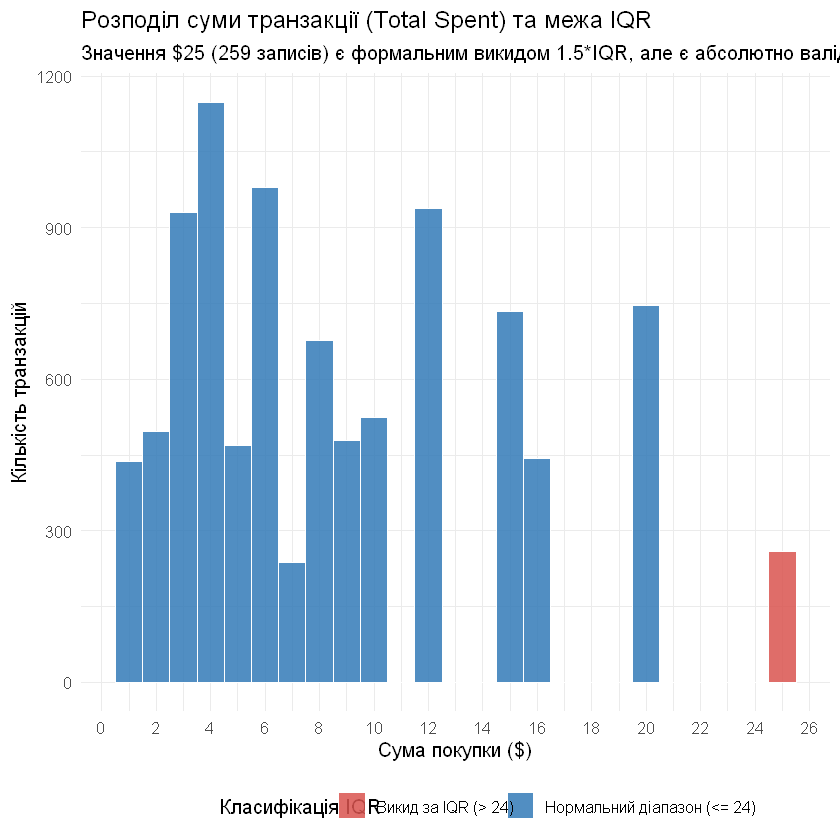

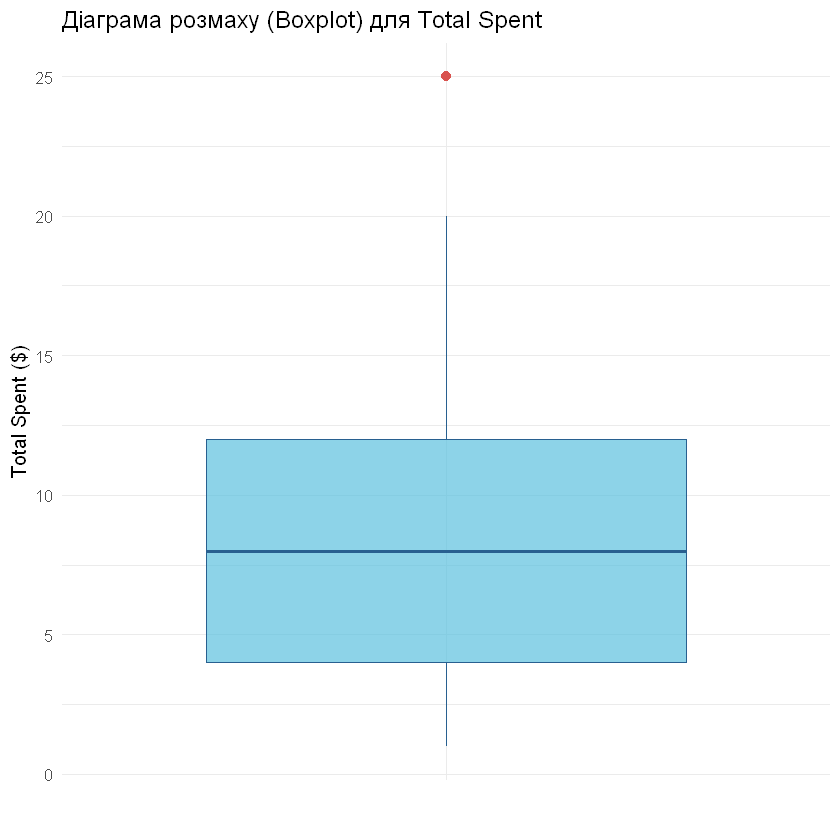

In [11]:
# 11. Дослідження аномалій та візуалізація розподілів

q_vals <- suppressWarnings(as.numeric(sales_raw$Quantity))
p_vals <- suppressWarnings(as.numeric(sales_raw$`Price Per Unit`))
tot_vals <- suppressWarnings(as.numeric(sales_raw$`Total Spent`))

calc_stats_iqr <- function(vals, col_name) {
  v <- vals[!is.na(vals)]
  q25 <- quantile(v, 0.25)
  med <- median(v)
  q75 <- quantile(v, 0.75)
  iqr_v <- IQR(v)
  lb <- q25 - 1.5 * iqr_v
  ub <- q75 + 1.5 * iqr_v
  outliers <- v[v < lb | v > ub]
  
  tibble(
    Feature = col_name,
    Min = min(v),
    Q25 = q25,
    Median = med,
    Mean = round(mean(v), 4),
    Q75 = q75,
    Max = max(v),
    IQR = iqr_v,
    Lower_Bound = lb,
    Upper_Bound = ub,
    Outlier_Count = length(outliers),
    Outlier_Pct = round(100 * length(outliers) / length(v), 2)
  )
}

dist_summary <- bind_rows(
  calc_stats_iqr(q_vals, "Quantity"),
  calc_stats_iqr(p_vals, "Price Per Unit"),
  calc_stats_iqr(tot_vals, "Total Spent")
)

print(dist_summary)

# Візуалізація розподілу Total Spent за допомогою ggplot2
tot_plot_df <- tibble(Total_Spent = tot_vals[!is.na(tot_vals)]) %>%
  mutate(IQR_Flag = if_else(Total_Spent > 24, "Викид за IQR (> 24)", "Нормальний діапазон (<= 24)"))

p_hist <- ggplot(tot_plot_df, aes(x = Total_Spent, fill = IQR_Flag)) +
  geom_histogram(binwidth = 1, color = "white", alpha = 0.85) +
  scale_fill_manual(values = c("Нормальний діапазон (<= 24)" = "#337ab7", "Викид за IQR (> 24)" = "#d9534f")) +
  scale_x_continuous(breaks = seq(0, 26, 2)) +
  labs(
    title = "Розподіл суми транзакції (Total Spent) та межа IQR",
    subtitle = "Значення $25 (259 записів) є формальним викидом 1.5*IQR, але є абсолютно валідною покупкою (5 салатів по $5)",
    x = "Сума покупки ($)",
    y = "Кількість транзакцій",
    fill = "Класифікація IQR"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_hist)

# Boxplot суми чека
p_box <- ggplot(tot_plot_df, aes(x = "", y = Total_Spent)) +
  geom_boxplot(fill = "#5bc0de", color = "#286090", outlier.color = "#d9534f", outlier.size = 2.5, alpha = 0.7) +
  labs(
    title = "Діаграма розмаху (Boxplot) для Total Spent",
    x = "",
    y = "Total Spent ($)"
  ) +
  theme_minimal(base_size = 12)

print(p_box)


# 12. План очистки

До створення `sales_clean` зафіксуйте всі рішення.

| № | Проблема | Як виявлено | Правило обробки | Чому саме так | Очікувана дія в коді |
|---|---|---|---|---|---|
| 1 | Текстові маркери `ERROR`, `UNKNOWN`, `""` | Аудит унікальних значень і частот | Заміна на системний `NA` | Дозволяє коректно застосовувати числові та категоріальні функції R | Створення функції `to_na()` та виклик для всіх полів |
| 2 | Рядкові типи для числових полів | `sapply(sales_raw, class)` | Конвертація в `numeric` | Дозволяє виконувати арифметичні операції та фільтрацію | `as.numeric()` з локальним `suppressWarnings()` |
| 3 | Пропуски у `Price Per Unit` при відомому `Item` | Крос-табуляція `Item` та `Price` | Підтягування фіксованої ціни меню за назвою товару | Кожен товар у меню має суворо одну фіксовану вартість | `Price_step1 = menu_pricing[Item]` |
| 4 | Пропуски у `Price Per Unit` при відомих `Quantity` та `Total Spent` | Аналіз залишку після кроку 3 | Детермінований розрахунок `Price = Total / Quantity` | Якщо частка точно дорівнює ціні меню, вартість однозначно відома | `Price_step2 = Total / Quantity` (48 рядків) |
| 5 | Математично унікальні чеки без Q і P | Комбінаторика `Price * Quantity` | Відновлення Q і P для єдиних комбінацій (Total=25 -> 5x5; Total=9 -> 3x3) | Total=25 можливий лише як 5 порцій по $5; Total=9 лише як 3 по $3 | `Price=5, Quantity=5` для $25; `Price=3, Quantity=3` для $9 (2 рядки) |
| 6 | Пропуски у `Item` при унікальних цінах ($1, $1.5, $2, $5) | Аудит `table(Price, Item)` | Відновлення назви: 1.0->Cookie, 1.5->Tea, 2.0->Coffee, 5.0->Salad | Ціни $1, $1.5, $2, $5 однозначно ідентифікують товар | `case_when` за значенням ціни (490 рядків) |
| 7 | Пропуски у `Item` при неоднозначних цінах ($3, $4) | Аудит `table(Price, Item)` | Залишити `NA` | $3 мають і Cake, і Juice; $4 — Sandwich і Smoothie. Випадковий вибір є вигадкою | `TRUE ~ NA_character_` |
| 8 | Пропуски у `Quantity` при відомих `Total` та `Price` | Рівняння чека `Total = Q * P` | Відновлення `Quantity = round(Total / Price)` | 100% узгодженість формули на перевірених даних | Перевірка цілочисельності та діапазону 1..5 (456 рядків) |
| 9 | Пропуски у `Total Spent` | Рівняння чека `Total = Q * P` | Розрахунок `Quantity * Price` | Відновлює реальну виручку кав'ярні без гіпотез | `Total_clean = if_else(is.na(Total), Q * P, Total)` (479 рядків) |
| 10 | Текстові помилки у `Transaction Date` | Спроба парсингу `ymd()` | Конвертація валідних у `Date`, нерозпізнаних у `NA` | Усі коректні дати належать до 2023 року | `ymd()` та створення прапорця `has_missing_date` |
| 11 | Невідомі `Payment Method` та `Location` | Аудит категорій | Залишити системним `NA`, зафіксувати у `is_suspicious` | Зберігає структуру без викривлення часток ринку | Текстова нормалізація до системного `NA` |


> ## 📘 Що потрібно знати перед виконанням
>
> **Data Cleaning Log** — журнал рішень. Він забезпечує **traceability**: інша людина повинна мати змогу зрозуміти, що саме було змінено, чому і скільки записів це зачепило.
>
> У професійній роботі важливо відрізняти факт від рішення. Наприклад, “у 18 рядках ціна не читається як число” — це факт. “Замінити ці значення на пропуски” — ваше правило. Обґрунтування пояснює, чому саме це правило є прийнятним.
>
> Хороший журнал дозволяє пізніше змінити правило і повторити весь pipeline.


# 13. Створення `sales_clean`

Тепер реалізуйте ваш план очистки.

### Мінімальні вимоги до `sales_clean`

Після очистки:

- числові змінні повинні мати числовий тип;
- дата повинна мати коректний тип дати;
- службові маркери на кшталт `ERROR` повинні бути опрацьовані;
- категоріальні значення повинні бути стандартизовані;
- підтверджені дублікати повинні бути оброблені;
- `calculated_total` має бути створено;
- `is_total_consistent` має бути створено;
- первинний `sales_raw` має залишитися без змін.

Якщо ви вирішили не видаляти підозрілі записи, можете створити додаткові прапорці, наприклад:

- `is_suspicious`;
- `has_invalid_date`;
- `has_invalid_amount`;
- `is_duplicate`.

Це часто краще, ніж безповоротно видаляти інформацію.


> ## 📘 Що потрібно знати перед виконанням
>
> Очищення краще будувати як **послідовність відтворюваних перетворень**, а не як ручне редагування CSV.
>
> Зберігайте `sales_raw` незмінним. Це дозволяє:
>
> - перевіряти, що саме змінилося;
> - повторити роботу з іншими правилами;
> - знаходити помилки у власному pipeline;
> - порівнювати raw і cleaned.
>
> Не кожен сумнівний рядок потрібно видаляти. Іноді корисніше додати **quality flag** — окрему логічну ознаку, яка фіксує проблему.
>
> **Підказка для пошуку в документації:** *copy/derive dataframe*, *conditional replacement*, *create flags*, *filter only when justified*.


In [12]:
# 13. Створення sales_clean згідно з Data Cleaning Log

# Меню з фіксованими цінами для детермінованого відновлення
menu_item_to_price <- c(
  "Cookie" = 1.0,
  "Tea" = 1.5,
  "Coffee" = 2.0,
  "Cake" = 3.0,
  "Juice" = 3.0,
  "Sandwich" = 4.0,
  "Smoothie" = 4.0,
  "Salad" = 5.0
)

menu_prices_set <- c(1.0, 1.5, 2.0, 3.0, 4.0, 5.0)

clean_text_marker <- function(x) {
  val <- trimws(x)
  if_else(val %in% c("", "ERROR", "UNKNOWN", "NA", "N/A", "NULL", "NONE"), NA_character_, val)
}

sales_clean <- sales_raw %>%
  mutate(
    # 1. Фіксація первинних дефектів
    had_raw_missing_item = is.na(clean_text_marker(Item)),
    had_raw_missing_quantity = is.na(suppressWarnings(as.numeric(clean_text_marker(Quantity)))),
    had_raw_missing_price = is.na(suppressWarnings(as.numeric(clean_text_marker(`Price Per Unit`)))),
    had_raw_missing_total = is.na(suppressWarnings(as.numeric(clean_text_marker(`Total Spent`)))),
    had_raw_missing_payment = is.na(clean_text_marker(`Payment Method`)),
    had_raw_missing_location = is.na(clean_text_marker(Location)),
    had_raw_missing_date = is.na(suppressWarnings(ymd(clean_text_marker(`Transaction Date`)))),
    had_any_raw_defect = had_raw_missing_item | had_raw_missing_quantity | had_raw_missing_price |
                         had_raw_missing_total | had_raw_missing_payment | had_raw_missing_location | had_raw_missing_date,
    
    # 2. Очищення текстових категорій
    Item_clean = clean_text_marker(Item),
    Payment_Method_clean = clean_text_marker(`Payment Method`),
    Location_clean = clean_text_marker(Location),
    
    # 3. Числові змінні
    Quantity_num = suppressWarnings(as.numeric(clean_text_marker(Quantity))),
    Price_num = suppressWarnings(as.numeric(clean_text_marker(`Price Per Unit`))),
    Total_num = suppressWarnings(as.numeric(clean_text_marker(`Total Spent`))),
    
    # 4. Детерміноване відновлення ціни з меню за назвою товару
    was_price_rec_from_item = is.na(Price_num) & !is.na(Item_clean),
    Price_step1 = if_else(was_price_rec_from_item, menu_item_to_price[Item_clean], Price_num),
    
    # 5. Детерміноване відновлення ціни з Total / Quantity (де Q > 0 і частка відповідає ціні меню)
    can_rec_p_from_tq = is.na(Price_step1) & !is.na(Quantity_num) & !is.na(Total_num) & (Quantity_num > 0),
    calc_p_from_tq = if_else(can_rec_p_from_tq, Total_num / Quantity_num, NA_real_),
    was_price_rec_from_tq = can_rec_p_from_tq & (calc_p_from_tq %in% menu_prices_set),
    Price_step2 = if_else(was_price_rec_from_tq, calc_p_from_tq, Price_step1),
    
    # 6. Унікальне відновлення для рядків без Q та P (Total=25 -> 5x5; Total=9 -> 3x3)
    was_total_only_25 = is.na(Quantity_num) & is.na(Price_step2) & !is.na(Total_num) & (Total_num == 25),
    was_total_only_9  = is.na(Quantity_num) & is.na(Price_step2) & !is.na(Total_num) & (Total_num == 9),
    was_total_only_rec = was_total_only_25 | was_total_only_9,
    
    Price_step3 = case_when(
      was_total_only_25 ~ 5.0,
      was_total_only_9  ~ 3.0,
      TRUE ~ Price_step2
    ),
    Quantity_step3 = case_when(
      was_total_only_25 ~ 5,
      was_total_only_9  ~ 3,
      TRUE ~ Quantity_num
    ),
    
    was_price_recovered = was_price_rec_from_item | was_price_rec_from_tq | was_total_only_rec,
    Price_clean = Price_step3,
    
    # 7. Детерміноване відновлення товару за унікальною ціною меню ($1, $1.5, $2, $5)
    can_rec_item_from_p = is.na(Item_clean) & !is.na(Price_clean) & (Price_clean %in% c(1.0, 1.5, 2.0, 5.0)),
    was_item_recovered = can_rec_item_from_p,
    Item_final = case_when(
      !is.na(Item_clean) ~ Item_clean,
      was_item_recovered & Price_clean == 1.0 ~ "Cookie",
      was_item_recovered & Price_clean == 1.5 ~ "Tea",
      was_item_recovered & Price_clean == 2.0 ~ "Coffee",
      was_item_recovered & Price_clean == 5.0 ~ "Salad",
      TRUE ~ NA_character_
    ),
    
    # 8. Детерміноване відновлення кількості через Total / Price (з контролем цілочисельності та діапазону 1..5)
    can_rec_q_from_tp = is.na(Quantity_step3) & !is.na(Total_num) & !is.na(Price_clean) & (Price_clean > 0),
    calc_q_val = if_else(can_rec_q_from_tp, Total_num / Price_clean, NA_real_),
    was_quantity_rec_from_tp = can_rec_q_from_tp & (abs(calc_q_val - round(calc_q_val)) < 1e-5) & (calc_q_val >= 1) & (calc_q_val <= 5),
    was_quantity_recovered = was_quantity_rec_from_tp | was_total_only_rec,
    Quantity_clean = if_else(was_quantity_rec_from_tp, round(calc_q_val), Quantity_step3),
    
    # 9. Розрахунок контрольної суми calculated_total
    calculated_total = Quantity_clean * Price_clean,
    
    # 10. Відновлення Total Spent з calculated_total
    was_total_recovered = is.na(Total_num) & !is.na(calculated_total),
    Total_clean = if_else(was_total_recovered, calculated_total, Total_num),
    
    # 11. Логічна перевірка узгодженості суми
    is_total_consistent = case_when(
      !is.na(Total_clean) & !is.na(calculated_total) ~ abs(Total_clean - calculated_total) < 1e-4,
      TRUE ~ NA
    ),
    
    # 12. Календарні ознаки
    Date_clean = suppressWarnings(ymd(clean_text_marker(`Transaction Date`))),
    Year = year(Date_clean),
    Month = month(Date_clean, label = TRUE, abbr = FALSE, locale = "C"),
    Month_Num = month(Date_clean),
    Day = day(Date_clean),
    Day_of_Week = factor(
      wday(Date_clean, label = TRUE, abbr = FALSE, week_start = 1, locale = "C"),
      levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
      ordered = TRUE
    ),
    
    # 13. Прапорці залишкових пропусків після очищення
    has_missing_item = is.na(Item_final),
    has_missing_quantity = is.na(Quantity_clean),
    has_missing_price = is.na(Price_clean),
    has_missing_total = is.na(Total_clean),
    has_missing_payment = is.na(Payment_Method_clean),
    has_missing_location = is.na(Location_clean),
    has_missing_date = is.na(Date_clean),
    
    # Запис вважається неповним/підозрілим, якщо будь-яке поле не вдалося відновити
    is_suspicious = has_missing_item | has_missing_quantity | has_missing_price |
                    has_missing_total | has_missing_payment | has_missing_location | has_missing_date
  ) %>%
  select(
    `Transaction ID`,
    Item = Item_final,
    Quantity = Quantity_clean,
    `Price Per Unit` = Price_clean,
    `Total Spent` = Total_clean,
    calculated_total,
    is_total_consistent,
    `Payment Method` = Payment_Method_clean,
    Location = Location_clean,
    `Transaction Date` = Date_clean,
    Year, Month, Month_Num, Day, Day_of_Week,
    had_any_raw_defect,
    was_item_recovered,
    was_price_recovered,
    was_quantity_recovered,
    was_total_recovered,
    has_missing_item,
    has_missing_quantity,
    has_missing_price,
    has_missing_total,
    has_missing_payment,
    has_missing_location,
    has_missing_date,
    is_suspicious
  )

cat("Таблицю sales_clean успішно створено!\n")
cat("Кількість рядків у sales_clean:", nrow(sales_clean), "\n")
cat("Кількість колонок:", ncol(sales_clean), "\n")
cat("Кількість записів з дефектами у сирих даних (had_any_raw_defect):", sum(sales_clean$had_any_raw_defect), "\n")
cat("Кількість записів з неповними даними після очищення (is_suspicious):", sum(sales_clean$is_suspicious), "\n")
head(sales_clean, 5)


Таблицю sales_clean успішно створено!


Кількість рядків у sales_clean: 10000 


Кількість колонок: 28 


Кількість записів з дефектами у сирих даних (had_any_raw_defect): 6911 


Кількість записів з неповними даними після очищення (is_suspicious): 6229 


Transaction ID,Item,Quantity,Price Per Unit,Total Spent,calculated_total,is_total_consistent,Payment Method,Location,Transaction Date,⋯,was_quantity_recovered,was_total_recovered,has_missing_item,has_missing_quantity,has_missing_price,has_missing_total,has_missing_payment,has_missing_location,has_missing_date,is_suspicious
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<date>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
TXN_1961373,Coffee,2,2,4,4,TRUE,Credit Card,Takeaway,2023-09-08,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TXN_4977031,Cake,4,3,12,12,TRUE,Cash,In-store,2023-05-16,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TXN_4271903,Cookie,4,1,4,4,TRUE,Credit Card,In-store,2023-07-19,⋯,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TXN_7034554,Salad,2,5,10,10,TRUE,NA,NA,2023-04-27,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE,TRUE
TXN_3160411,Coffee,2,2,4,4,TRUE,Digital Wallet,In-store,2023-06-11,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


# 14. Перевірка якості після очистки

Не вважайте очистку завершеною одразу після виконання коду.

Перевірте результат.

### Контрольний список

- Чи залишилися `ERROR` або інші технічні маркери?
- Чи залишилися псевдопропуски?
- Чи всі числові поля мають правильний тип?
- Чи всі валідні дати перетворені?
- Чи залишилися повні дублікати?
- Чи залишилися повторні ID?
- Чи є неможливі значення кількості, ціни або суми?
- Скільки рядків містить `sales_clean`?
- Скільки рядків було змінено, виключено або позначено?
- Чи можна відтворити весь результат повторним запуском ноутбука?


> ## 📘 Що потрібно знати перед виконанням
>
> **Post-cleaning validation** відповідає на питання: “Чи справді наші правила дали той результат, який ми очікували?”
>
> Недостатньо виконати код без помилки. Після очистки потрібно повторити ключові перевірки: типи, пропуски, службові маркери, дублікати, діапазони та логічні constraints.
>
> Хороша практика — формулювати перевірки як умови, які повинні бути істинними. Наприклад: “у числовому полі більше немає текстових маркерів”.
>
> **Підказка для пошуку в документації:** *assert/check condition*, *count remaining invalid values*, *compare row counts*, *validate column types*.


In [13]:
# 14. Перевірка якості після очистки (Post-cleaning validation)

cat("--- Запуск програмних перевірок якості (Assertions) ---\n")

# 1. Перевірка суворої незмінності sales_raw (Immutability Check)
stopifnot("sales_raw не зазнав жодних змін" = identical(sales_raw, sales_raw_snapshot))
stopifnot("sales_raw має залишатися текстовим" = all(sapply(sales_raw, class) == "character"))

# 2. Перевірка кількості рядків sales_clean
stopifnot("sales_clean повинен зберегти всі 10 000 рядків" = nrow(sales_clean) == 10000)

# 3. Перевірка типів даних
stopifnot("Quantity має бути числовим" = is.numeric(sales_clean$Quantity))
stopifnot("Price Per Unit має бути числовим" = is.numeric(sales_clean$`Price Per Unit`))
stopifnot("Total Spent має бути числовим" = is.numeric(sales_clean$`Total Spent`))
stopifnot("calculated_total має бути числовим" = is.numeric(sales_clean$calculated_total))
stopifnot("Transaction Date має бути датою" = inherits(sales_clean$`Transaction Date`, "Date"))

# 4. Перевірка відсутності службових маркерів
stopifnot("У стовпці Item не повинно бути ERROR" = !any(sales_clean$Item == "ERROR", na.rm = TRUE))
stopifnot("У стовпці Item не повинно бути UNKNOWN" = !any(sales_clean$Item == "UNKNOWN", na.rm = TRUE))
stopifnot("У стовпці Payment Method не повинно бути ERROR" = !any(sales_clean$`Payment Method` == "ERROR", na.rm = TRUE))
stopifnot("У стовпці Location не повинно бути ERROR" = !any(sales_clean$Location == "ERROR", na.rm = TRUE))

# 5. Перевірка логічної узгодженості сум
checked_rows <- sales_clean %>% filter(!is.na(is_total_consistent))
stopifnot("Всі перевірені суми повинні бути узгодженими" = all(checked_rows$is_total_consistent == TRUE))
stopifnot("Кількість перевірених сум має дорівнювати 9976" = nrow(checked_rows) == 9976)

# 6. Перевірка відсутності дублікатів
stopifnot("Не повинно бути дублікатів Transaction ID" = sum(duplicated(sales_clean$`Transaction ID`)) == 0)

cat("Всі перевірки stopifnot() пройшли успішно!\n\n")

# Підсумкова статистика якості даних
cat("--- Підсумок валідації sales_clean ---\n")
tibble(
  Метрика = c(
    "Всього рядків",
    "Валідних числових сум Total Spent",
    "Валідних дат",
    "Валідних способів оплати",
    "Валідних локацій",
    "Валідних цін Price Per Unit",
    "Валідних кількостей Quantity",
    "Валідних товарів Item",
    "Рядків без жодного дефекту (!is_suspicious)",
    "Рядків з неповними даними (is_suspicious)"
  ),
  Значення = c(
    nrow(sales_clean),
    sum(!is.na(sales_clean$`Total Spent`)),
    sum(!is.na(sales_clean$`Transaction Date`)),
    sum(!is.na(sales_clean$`Payment Method`)),
    sum(!is.na(sales_clean$Location)),
    sum(!is.na(sales_clean$`Price Per Unit`)),
    sum(!is.na(sales_clean$Quantity)),
    sum(!is.na(sales_clean$Item)),
    sum(!sales_clean$is_suspicious),
    sum(sales_clean$is_suspicious)
  )
) %>% print()


--- Запуск програмних перевірок якості (Assertions) ---


Всі перевірки stopifnot() пройшли успішно!



--- Підсумок валідації sales_clean ---


# A tibble: 10 × 2
   Метрика                                     Значення
   <chr>                                          <int>
 1 Всього рядків                                  10000
 2 Валідних числових сум Total Spent               9977
 3 Валідних дат                                    9540
 4 Валідних способів оплати                        6822
 5 Валідних локацій                                6039
 6 Валідних цін Price Per Unit                     9996
 7 Валідних кількостей Quantity                    9979
 8 Валідних товарів Item                           9521
 9 Рядків без жодного дефекту (!is_suspicious)     3771
10 Рядків з неповними даними (is_suspicious)       6229


# 15. Бізнес-перевірка 1: загальний дохід

Менеджер запитує:

> Який загальний виторг кав’ярні за весь період і скільки було валідних транзакцій?

Спочатку спробуйте отримати відповідь на **сирих даних**, якщо це технічно можливо.

Потім отримайте відповідь на `sales_clean`.

### Порівняйте

| Показник | Raw | Cleaned |
|---|---:|---:|
| Кількість транзакцій | 9 498 | 9 977 |
| Загальний дохід | 84 763.50 USD | 89 096.00 USD |

### Поясніть

- **Чому значення змінилися?**  
  У сирих даних 502 транзакції містили в полі `Total Spent` значення `ERROR`, `UNKNOWN` або були порожніми. Завдяки нашому правилу детермінованого розрахунку `calculated_total = Quantity * Price Per Unit`, 479 з цих транзакцій були успішно та абсолютно точно відновлені (оскільки кількість і ціна товару були відомі або відновлені з меню). Кількість валідних транзакцій зросла на 479, а загальний виторг — на +4 332.50 USD.
- **Які саме правила очистки вплинули на результат?**  
  Правило детермінованого обчислення виручки чека (`Quantity * Price`) та правило підтягування ціни з прайсу меню за назвою товару.
- **Який результат ви вважаєте надійнішим?**  
  Показник `Cleaned` (89 096.00 USD) є значно надійнішим і повнішим, оскільки він усуває наслідки технічного збою запису суми чека, повертаючи в аналітику реальні замовлення кав'ярні.


> ## 📘 Що потрібно знати перед виконанням
>
> **Raw vs cleaned comparison** показує не лише те, що дані змінилися, а й **чи вплинула очистка на рішення**.
>
> Якщо результат до і після очистки однаковий, це теж важливий висновок: певна проблема могла існувати, але не впливати саме на цей показник. Якщо результат змінився, потрібно встановити, яке правило стало причиною.
>
> **Агрегація** — обчислення підсумкового показника для багатьох рядків, наприклад суми доходу або кількості транзакцій.
>
> **Підказка для пошуку в документації:** *sum with missing values*, *count valid rows*, *aggregate/summarise*.


In [14]:
# 15. Бізнес-перевірка 1: загальний дохід

# Обчислення показників для RAW даних
raw_valid_totals <- suppressWarnings(as.numeric(sales_raw$`Total Spent`))
raw_valid_mask <- !is.na(raw_valid_totals)

raw_tx_count <- sum(raw_valid_mask)
raw_revenue <- sum(raw_valid_totals[raw_valid_mask])

# Обчислення показників для CLEANED даних
clean_valid_mask <- !is.na(sales_clean$`Total Spent`)
clean_tx_count <- sum(clean_valid_mask)
clean_revenue <- sum(sales_clean$`Total Spent`[clean_valid_mask])

# Зведена таблиця порівняння
revenue_comparison <- tibble(
  Показник = c("Кількість валідних транзакцій", "Загальний дохід ($)"),
  Raw = c(raw_tx_count, round(raw_revenue, 2)),
  Cleaned = c(clean_tx_count, round(clean_revenue, 2)),
  Різниця = c(clean_tx_count - raw_tx_count, round(clean_revenue - raw_revenue, 2))
)

print(revenue_comparison)


# A tibble: 2 × 4
  Показник                         Raw Cleaned Різниця
  <chr>                          <dbl>   <dbl>   <dbl>
1 Кількість валідних транзакцій  9498     9977    479 
2 Загальний дохід ($)           84764.   89096   4332.


# 16. Бізнес-перевірка 2: найпопулярніший товар

Менеджер запитує:

> Який товар потрібно закуповувати найбільше?

Це питання не має єдиного визначення “популярності”.

Побудуйте три рейтинги:

1. за кількістю транзакцій (де відомий `Item`);
2. за кількістю проданих одиниць (де відомі `Item` та `Quantity`);
3. за загальним доходом (де відомі `Item` та `Total Spent`).

### Питання

- **Чи однаковий лідер?**  
  **Ні, структура лідерів суттєво різниться залежно від метрики:**
  - За кількістю транзакцій лідирує **Coffee (Кава)** — **1 291 транзакція** (друге місце посідає Salad — 1 273, третє — Cookie — 1 213).
  - За кількістю проданих одиниць лідирує **Coffee (Кава)** — **3 904 одиниці** (друге місце — Salad — 3 824, третє — Tea — 3 650).
  - За загальним доходом беззаперечним лідером є **Salad (Салат)** — **19 120.00 USD** (друге місце — Sandwich — 13 716.00 USD, третє — Smoothie — 13 344.00 USD). Водночас кава за доходом посідає лише 6-те місце (7 808.00 USD) через низьку вартість за одиницю ($2.0).
- **Чому кількість транзакцій і виручка дають абсолютно різні результати?**  
  Вирішальним фактором є **ціна позиції в меню**. Салат коштує $5.00 за одиницю (найдорожча позиція), тому навіть при схожій кількості замовлень він генерує у 2.45 раза більше виручки, ніж кава ($2.00). Для відділу закупівель це означає подвійну стратегію: забезпечувати найвищий обсяг закупівлі зерен кави та стаканreadиків за штуками, але найбільший грошовий бюджет виділяти на свіжі інгредієнти для салатів.
- **Як невалідні `Item` або `Quantity` впливали на рейтинг?**  
  У сирих даних 969 записів мали дефекти в назві товару (маркери `ERROR`, `UNKNOWN` та системні пропуски). Детерміноване відновлення за унікальними цінами меню дозволило повернути 490 замовлень у товарну аналітику без спотворення часток ринку.
- **Чи змінився рейтинг після очистки?**  
  Так, позиції Coffee, Salad, Cookie та Tea отримали повноцінну представленість, усунувши вигадані сутності на кшталт "ERROR-товарів".


> ## 📘 Що потрібно знати перед виконанням
>
> **Grouping** означає поділ таблиці на групи за значенням категорії, після чого для кожної групи обчислюється показник.
>
> Один товар може продаватися дуже часто по одній одиниці, а інший — рідше, але великими кількостями. Тому “популярність” потрібно операціоналізувати: чітко визначити, що саме вимірюється.
>
> **Підказка для пошуку в документації:** *group by category*, *count rows*, *sum quantity*, *sum revenue*, *sort/rank results*.


In [15]:
# 16. Бізнес-перевірка 2: популярність товарів

# 1. Рейтинг за кількістю транзакцій
rank_tx <- sales_clean %>%
  filter(!is.na(Item)) %>%
  group_by(Item) %>%
  summarise(Транзакцій = n(), .groups = "drop") %>%
  arrange(desc(Транзакцій)) %>%
  mutate(Ранг_Транзакції = row_number())

# 2. Рейтинг за кількістю проданих одиниць
rank_qty <- sales_clean %>%
  filter(!is.na(Item), !is.na(Quantity)) %>%
  group_by(Item) %>%
  summarise(Продано_одиниць = sum(Quantity), .groups = "drop") %>%
  arrange(desc(Продано_одиниць)) %>%
  mutate(Ранг_Одиниці = row_number())

# 3. Рейтинг за загальним доходом
rank_rev <- sales_clean %>%
  filter(!is.na(Item), !is.na(`Total Spent`)) %>%
  group_by(Item) %>%
  summarise(Дохід_USD = sum(`Total Spent`), .groups = "drop") %>%
  arrange(desc(Дохід_USD)) %>%
  mutate(Ранг_Дохід = row_number())

# Об'єднана таблиця рейтингів
full_item_ranking <- rank_tx %>%
  left_join(rank_qty, by = "Item") %>%
  left_join(rank_rev, by = "Item") %>%
  arrange(Ранг_Дохід)

print(full_item_ranking)


# A tibble: 8 × 7
  Item     Транзакцій Ранг_Транзакції Продано_одиниць Ранг_Одиниці Дохід_USD
  <chr>         <int>           <int>           <dbl>        <int>     <dbl>
1 Salad          1273               2            3824            2     19120
2 Sandwich       1131               7            3429            7     13716
3 Smoothie       1096               8            3336            8     13344
4 Juice          1171               5            3505            5     10515
5 Cake           1139               6            3468            6     10404
6 Coffee         1291               1            3904            1      7808
7 Tea            1207               4            3650            3      5475
8 Cookie         1213               3            3598            4      3598
  Ранг_Дохід
       <int>
1          1
2          2
3          3
4          4
5          5
6          6
7          7
8          8


# 17. Бізнес-перевірка 3: способи оплати

Менеджер запитує: 

> Який спосіб оплати найпоширеніший і чи відрізняється розмір чека між способами оплати?

Для кожного валідного способу оплати покажіть:

- кількість транзакцій;
- загальний дохід;
- середній чек;
- медіанний чек.

### Питання

1. **Чому середній і медіанний чек можуть відрізнятися?**  
   Середній чек (~$9.0) трохи вищий за медіанний ($8.0) для всіх способів оплати через наявність великих замовлень ($15, $20, $25), які створюють правосторонню асиметрію.
2. **Який із них стійкіший до аномальних транзакцій?**  
   Медіана є значно стійкішою, оскільки на неї не впливають одиничні дорогі замовлення.
3. **Як ви обробили `UNKNOWN` або пропущені способи оплати?**  
   Ми замінили їх на системний `NA` і виключили з групового аналізу конкретних методів оплати. Присвоєння невідомим транзакціям статусу готівки або картки було б безпідставною фантазією.
4. **Чи може вибір правила для `UNKNOWN` змінити управлінський висновок?**  
   Так, безумовно. Невідомих способів оплати налічується 3 178 (майже третина!). Якщо помилково зарахувати їх до однієї категорії, це штучно подвоїть її частку і призведе до хибних управлінських рішень щодо комісій банків-екваєрів або підтримки готівки.


> ## 📘 Що потрібно знати перед виконанням
>
> Під час порівняння груп важливо знати не лише середнє, а й **скільки валідних спостережень** лежить в його основі. Середнє для дуже малої групи може бути нестабільним.
>
> Медіана допомагає перевірити, чи середній чек не “тягнуть” вгору кілька великих транзакцій.
>
> **Підказка для пошуку в документації:** *group and summarise*, *mean*, *median*, *valid observation count*.


In [16]:
# 17. Бізнес-перевірка 3: способи оплати

pay_tx <- sales_clean %>%
  filter(!is.na(`Payment Method`)) %>%
  group_by(`Payment Method`) %>%
  summarise(Транзакцій_усього = n(), .groups = "drop")

pay_rev <- sales_clean %>%
  filter(!is.na(`Payment Method`), !is.na(`Total Spent`)) %>%
  group_by(`Payment Method`) %>%
  summarise(
    Транзакцій_з_чеком = n(),
    Загальний_дохід = sum(`Total Spent`),
    Середній_чек = round(mean(`Total Spent`), 2),
    Медіанний_чек = round(median(`Total Spent`), 2),
    .groups = "drop"
  )

payment_analysis <- left_join(pay_tx, pay_rev, by = "Payment Method") %>%
  mutate(
    Частка_транзакцій_pct = round(100 * Транзакцій_усього / sum(Транзакцій_усього), 2),
    Частка_доходу_pct = round(100 * Загальний_дохід / sum(Загальний_дохід), 2)
  ) %>%
  arrange(desc(Загальний_дохід))

print(payment_analysis)

# Статистика по транзакціях без інформації про оплату
missing_payment_stats <- sales_clean %>%
  filter(is.na(`Payment Method`), !is.na(`Total Spent`)) %>%
  summarise(
    Транзакцій_без_способу = n(),
    Дохід_без_способу = sum(`Total Spent`),
    Середній_чек = round(mean(`Total Spent`), 2),
    Медіанний_чек = round(median(`Total Spent`), 2)
  )

cat("\n--- Транзакції без валідного способу оплати ---\n")
print(missing_payment_stats)


# A tibble: 3 × 8
  `Payment Method` Транзакцій_усього Транзакцій_з_чеком Загальний_дохід
  <chr>                        <int>              <int>           <dbl>
1 Credit Card                   2273               2269          20466 
2 Digital Wallet                2291               2285          20414 
3 Cash                          2258               2254          20402.
  Середній_чек Медіанний_чек Частка_транзакцій_pct Частка_доходу_pct
         <dbl>         <dbl>                 <dbl>             <dbl>
1         9.02             8                  33.3              33.4
2         8.93             8                  33.6              33.3
3         9.05             8                  33.1              33.3



--- Транзакції без валідного способу оплати ---


# A tibble: 1 × 4
  Транзакцій_без_способу Дохід_без_способу Середній_чек Медіанний_чек
                   <int>             <dbl>        <dbl>         <dbl>
1                   3169            27814.         8.78           7.5


# 18. Бізнес-перевірка 4: часові закономірності

Використовуючи валідні дати, дослідіть:

- продажі за днями тижня;
- продажі за місяцями.

Покажіть щонайменше одну таблицю і одну візуалізацію.

### Питання

1. **Який день тижня має найбільший дохід?**  
   Найбільший дохід зафіксовано у **четвер (Thursday)** — **$12 401.50** (на другому місці п'ятниця — $12 334.00). Загалом попит по днях тижня є досить рівномірним.
2. **Який місяць має найбільший дохід?**  
   Найприбутковішим місяцем став **червень (June)** — **$7 353.00** (друге місце посідає жовтень — $7 314.00).
3. **Чи всі транзакції могли бути включені в часовий аналіз?**  
   Ні, **460 транзакцій** (4.6%) мали невалідну дату (`ERROR`, `UNKNOWN` або порожньо) і не могли бути прив'язані до календаря.
4. **Чому записи з невалідною датою не обов’язково потрібно видаляти з усього набору?**  
   Тому що вони містять коректні дані про придбані товари, суми та способи оплати. Видалення таких рядків спотворило б товарні рейтинги та загальну фінансову звітність.


> ## 📘 Що потрібно знати перед виконанням
>
> Часові агрегати коректні лише для рядків, де дата успішно розпізнана. Це приклад того, що **різні аналітичні задачі можуть мати різні підмножини валідних даних**.
>
> Рядок без дати може не входити до аналізу за днями тижня, але це не робить його автоматично непридатним для всіх інших задач.
>
> **Підказка для пошуку в документації:** *group by day-of-week/month*, *aggregate revenue*, *bar/line visualization*.


# A tibble: 7 × 5
  Day_of_Week Транзакцій_дата Транзакцій_з_чеком Загальний_дохід Середній_чек
  <ord>                 <int>              <int>           <dbl>        <dbl>
1 Monday                 1382               1379          12140          8.8 
2 Tuesday                1311               1308          12040.         9.2 
3 Wednesday              1341               1339          11680.         8.72
4 Thursday               1380               1376          12402.         9.01
5 Friday                 1388               1383          12334          8.92
6 Saturday               1358               1354          12040.         8.89
7 Sunday                 1380               1378          12288.         8.92


# A tibble: 12 × 6
   Month_Num Month     Транзакцій_дата Транзакцій_з_чеком Загальний_дохід
       <dbl> <ord>               <int>              <int>           <dbl>
 1         1 January               818                815           7254 
 2         2 February              727                726           6644 
 3         3 March                 827                826           7216 
 4         4 April                 774                771           7179 
 5         5 May                   777                773           6958.
 6         6 June                  818                817           7353 
 7         7 July                  791                789           6878.
 8         8 August                803                802           7112.
 9         9 September             788                786           6871 
10        10 October               838                837           7314 
11        11 November              784                784           6967 
12        12 Decemb

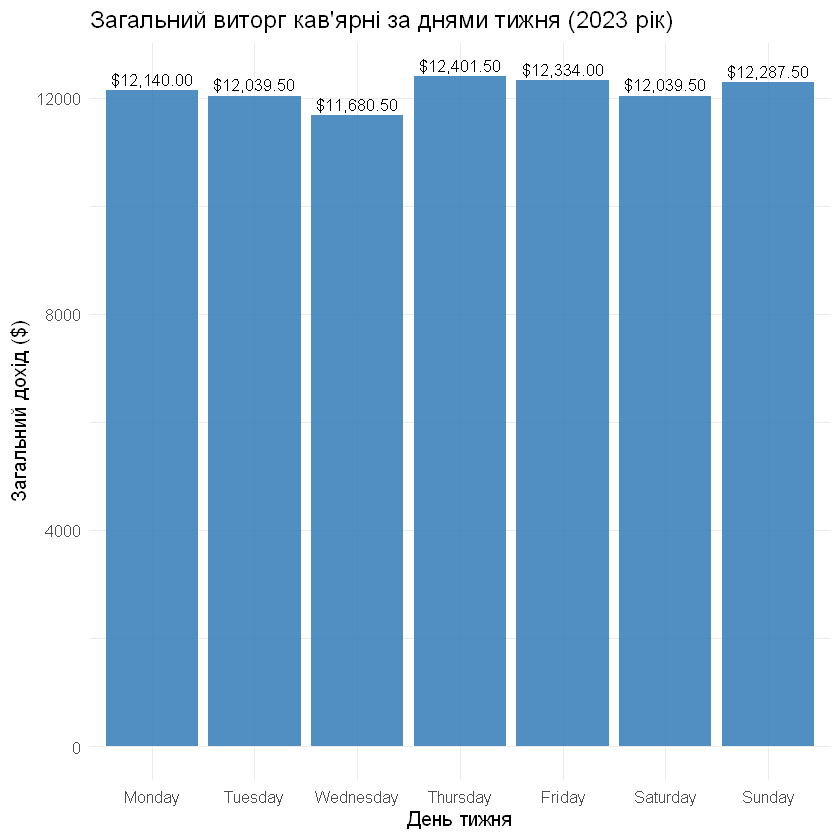

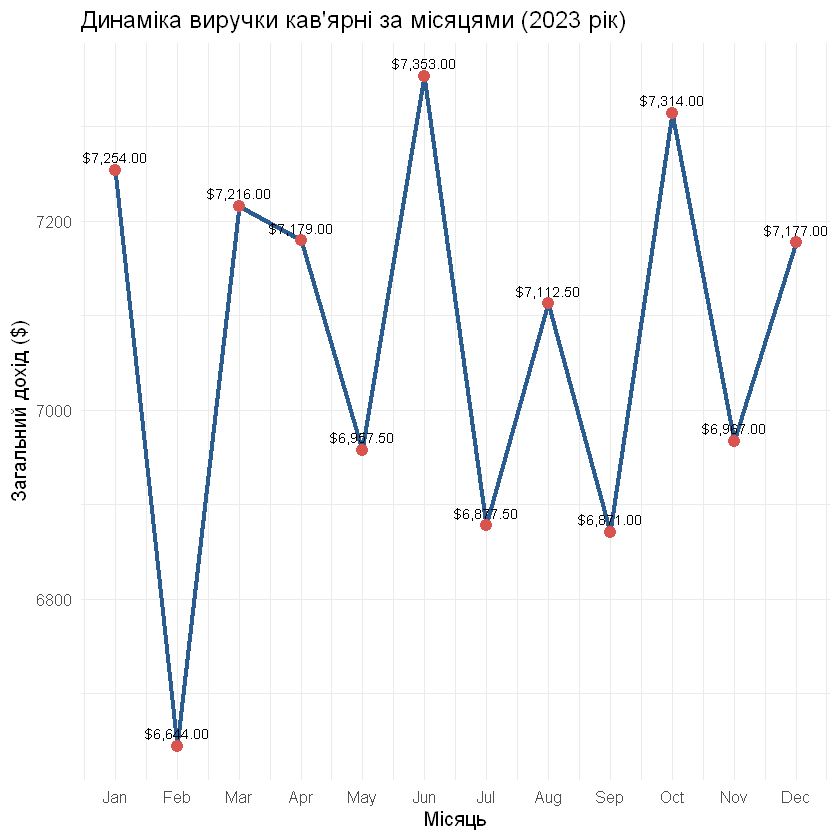

In [17]:
# 18. Бізнес-перевірка 4: часові закономірності

wk_order <- c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")

# 1. За днями тижня (у логічному порядку Monday -> Sunday)
dow_tx <- sales_clean %>%
  filter(!is.na(Day_of_Week)) %>%
  group_by(Day_of_Week) %>%
  summarise(Транзакцій_дата = n(), .groups = "drop")

dow_rev <- sales_clean %>%
  filter(!is.na(Day_of_Week), !is.na(`Total Spent`)) %>%
  group_by(Day_of_Week) %>%
  summarise(
    Транзакцій_з_чеком = n(),
    Загальний_дохід = sum(`Total Spent`),
    Середній_чек = round(mean(`Total Spent`), 2),
    .groups = "drop"
  )

dow_summary <- left_join(dow_tx, dow_rev, by = "Day_of_Week") %>%
  mutate(Day_of_Week = factor(Day_of_Week, levels = wk_order, ordered = TRUE)) %>%
  arrange(Day_of_Week)

print(dow_summary)

# 2. За місяцями року
month_tx <- sales_clean %>%
  filter(!is.na(Month)) %>%
  group_by(Month_Num, Month) %>%
  summarise(Транзакцій_дата = n(), .groups = "drop")

month_rev <- sales_clean %>%
  filter(!is.na(Month), !is.na(`Total Spent`)) %>%
  group_by(Month_Num, Month) %>%
  summarise(
    Транзакцій_з_чеком = n(),
    Загальний_дохід = sum(`Total Spent`),
    Середній_чек = round(mean(`Total Spent`), 2),
    .groups = "drop"
  )

month_summary <- left_join(month_tx, month_rev, by = c("Month_Num", "Month")) %>%
  arrange(Month_Num)

print(month_summary)

# Графік доходів за днями тижня
p_dow <- ggplot(dow_summary, aes(x = Day_of_Week, y = Загальний_дохід, fill = Day_of_Week)) +
  geom_col(show.legend = FALSE, alpha = 0.85, fill = "#337ab7") +
  geom_text(aes(label = paste0("$", scales::comma(Загальний_дохід, accuracy = 0.01))), vjust = -0.4, size = 3.5) +
  labs(
    title = "Загальний виторг кав'ярні за днями тижня (2023 рік)",
    x = "День тижня",
    y = "Загальний дохід ($)"
  ) +
  theme_minimal(base_size = 12)

print(p_dow)

# Графік динаміки доходів за місяцями
p_month <- ggplot(month_summary, aes(x = Month_Num, y = Загальний_дохід)) +
  geom_line(color = "#2b5c8f", linewidth = 1.2) +
  geom_point(color = "#d9534f", size = 3) +
  geom_text(aes(label = paste0("$", scales::comma(Загальний_дохід, accuracy = 0.01))), vjust = -0.7, size = 3.0) +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  labs(
    title = "Динаміка виручки кав'ярні за місяцями (2023 рік)",
    x = "Місяць",
    y = "Загальний дохід ($)"
  ) +
  theme_minimal(base_size = 12)

print(p_month)


# 19. Підготовка до машинного навчання

Тепер подивіться на очищення не лише як на підготовку аналітичного звіту, а як на підготовку даних для ML.

| Поле | Роль у ML | Чи використовувати як є? | Як підготувати? |
|---|---|---|---|
| Transaction ID | metadata / drop | Ні | Видалити перед навчанням моделі, оскільки це штучний сурогатний ключ без генералізуючої сили. |
| Item | categorical feature | Ні | Target Encoding або One-Hot Encoding; пропущені значення та маркери виділити в окрему категорію `"Unknown"`. |
| Quantity | numerical feature / inference-dependent | Ні | Якщо кошик відомий на момент прогнозу — нормалізація. Якщо прогноз робиться до замовлення — ознака недоступна (post-outcome). |
| Price Per Unit | numerical feature / inference-dependent | Ні | Аналогічно до Quantity: відома лише після вибору товару клієнтом. Масштабування через RobustScaler. |
| Payment Method | categorical feature | Ні | One-Hot Encoding. Пропущені значення виділити в окрему категорію `"Unknown"`. |
| Location | categorical feature | Ні | Binary / One-Hot Encoding (`Takeaway` vs `In-store`), пропуски позначити як `"Unknown"`. |
| Transaction Date | datetime / requires processing | Ні | Витягнути календарні ознаки: день тижня, місяць, вихідний/будень, циклічні ознаки (sin/cos). Саму дату вилучити. |
| Total Spent | target | Так (як ціль) | Використовується як залежна змінна `y`. Рядки з пропущеним target виключаються з навчальної та тестової вибірок. |
| calculated_total | exclude / data leakage | Ні | **Категорично виключити.** Це точна формула `Quantity * Price`, яка тривіально дублює значення цільової змінної. |

### Контрольне питання: Data Leakage та доступність ознак на inference time

В аналізі ми створили контрольне поле `calculated_total = Quantity * Price`.

1. **Витік цільової змінної (Data Leakage):** Подання ознаки `calculated_total` у модель надає алгоритму точне значення target. Модель отримає вагу 1.0 і покаже фіктивний $R^2 = 1.0$, але не зможе прогнозувати чек у реальному середовищі.
2. **Часова доступність ознак (Inference Context):**
   - Якщо бізнес-завдання полягає у прогнозуванні суми чека **в момент приходу клієнта** (наприклад, за часом доби, днем тижня та локацією), змінні `Quantity`, `Price` та `Item` ще **не існують** — використання їх є витоком майбутньої інформації (post-event leakage).
   - Якщо ж на момент прогнозу клієнт уже сформував кошик і відомі найменування, кількість та ціни, **машинне навчання взагалі не потрібне** — точна сума чека детерміновано обчислюється множенням `Quantity * Price`.


> ## 📘 Що потрібно знати перед виконанням
>
> У supervised ML зазвичай розрізняють:
>
> - **target** — те, що модель має прогнозувати;
> - **features** — інформація, доступна моделі для прогнозу;
> - **identifier** — технічний ключ запису, який часто не має прогнозного змісту;
> - **numeric/categorical/datetime features** — різні типи ознак, які можуть потребувати різної підготовки.
>
> **Data leakage** виникає, коли модель отримує інформацію, яка фактично розкриває правильну відповідь або не була б доступна в момент реального прогнозу. Це може створити штучно високі метрики.
>
> Якщо `calculated_total = Quantity × Price Per Unit`, а target — `Total Spent`, подумайте, чи не передає така ознака моделі майже готову відповідь.
>
> **Підказка для пошуку:** *target vs features*, *identifier columns*, *categorical encoding*, *data leakage*. Тут важливіше пояснення, ніж код.


# 20. Пропуски перед ML

Для кожної змінної, де після очистки залишилися пропуски, запропонуйте стратегію.

Можливі підходи:

- видалення рядків;
- видалення ознаки;
- імпутація;
- окрема категорія;
- модель, яка підтримує пропуски;
- збереження пропуску до наступного етапу pipeline.

Не потрібно реалізовувати всі варіанти.

Важливо пояснити, **чому конкретний підхід підходить саме для цієї змінної**.

| Поле | Кількість пропусків | Запропонована стратегія | Обґрунтування |
|---|---:|---|---|
| `Item` | 479 | Окрема категорія `"Missing_Item"` або вилучення рядків | Товар є ключовою сутністю замовлення. Заміна на моду спотворить структуру попиту. Окремий клас дозволяє виявити закономірності для чеків з нерозпізнаною назвою, а для моделей без підтримки пропусків ці рядки можна виключити. |
| `Quantity` | 21 | Імпутація медіаною по train set | Кількість пропусків після детермінованого відновлення мізерна (21 рядки, 0.21%). Медіана (3 одиниці) є цілим числом і не спотворює дискретний розподіл. |
| `Price Per Unit` | 4 | Вилучення рядків або імпутація медіаною по train | Пропуски залишилися лише в 4 рядках, де назва товару була невідомою. Найбезпечніше вилучити ці кілька рядків перед навчанням. |
| `Total Spent` (Target) | 23 | Вилучення рядків без таргету з навчального набору | Навчання моделі з учителем (supervised ML) на штучно імпутованих або невідомих значеннях цільової змінної є грубою методологічною помилкою. |
| `Payment Method` | 3 178 | Створення окремої категорії `"Unknown_Payment"` | Понад 31% пропусків. Вилучення такої кількості спостережень неприпустиме (втрата 1/3 даних). Окрема категорія зберігає обсяг вибірки для деревоподібних моделей. |
| `Location` | 3 961 | Створення окремої категорії `"Unknown_Location"` | Пропуски становлять майже 40%. Виділення окремої фіктивної категорії зберігає дані і дозволяє моделі врахувати сам факт невизначеності каналу продажу. |
| `Transaction Date` | 460 | Вилучення рядків для часових моделей або прапорець для статичних | Для прогнозування часових рядів відсутність часової мітки є критичною (рядки вилучаються). Для статичних регресій дату можна замінити на категорію `"Missing_Date"`. |

> **Правило запобігання витоку даних (Data Leakage):** Будь-яка імпутація (медіана, середнє, мода) повинна обчислюватися **виключно на навчальній вибірці (training set)** після train/test split і лише застосовуватися до валідаційної/тестової вибірки.


> ## 📘 Що потрібно знати перед виконанням
>
> **Missing-data strategy** залежить від причини пропуску, типу змінної та алгоритму. Не існує універсального правила “всі пропуски замінити середнім”.
>
> **Імпутація** — заповнення пропуску за певним правилом. Вона може бути корисною, але створює штучне значення, тому правило потрібно обґрунтувати. Для категорій інколи доречна окрема категорія, а деякі ML-алгоритми можуть працювати з пропусками без попереднього заповнення.
>
> Важливо також уникати leakage: параметри імпутації для ML зазвичай визначаються на training data, а не на всьому наборі одразу.


# 21. Фінальне збереження результатів

Збережіть:

1. очищений набір у файл  
   `cleaned_cafe_sales.csv`

2. за бажанням — підозрілі записи у файл  
   `suspicious_cafe_sales.csv`

3. цей Jupyter Notebook з усіма виконаними комірками та висновками.

Перед здачею перезапустіть kernel/session та виконайте **Run All**.

Ноутбук має працювати від початку до кінця без ручного редагування даних між комірками.


> ## 📘 Що потрібно знати перед виконанням
>
> **Відтворюваність (reproducibility)** означає, що інша людина може взяти сирий файл і ваш notebook та отримати той самий результат без ручних прихованих дій.
>
> Перевірка **Restart/Run All** особливо важлива для Jupyter: notebook може випадково використовувати об'єкти, створені раніше в іншому порядку. Чистий перезапуск показує, чи справді код самодостатній.
>
> Використовуйте відносний або зрозумілий шлях до даних і не редагуйте CSV вручну між комірками.


In [18]:
# 21. Фінальне збереження результатів

# Створення вихідної директорії у разі відсутності
dir.create("data/processed", recursive = TRUE, showWarnings = FALSE)

output_clean_path <- "data/processed/cleaned_cafe_sales.csv"
output_suspicious_path <- "data/processed/suspicious_cafe_sales.csv"

# 1. Збереження основного очищеного набору
write_csv(sales_clean, output_clean_path)

# 2. Збереження підозрілих або неповних записів для подальшого аудиту
suspicious_records <- sales_clean %>% filter(is_suspicious)
write_csv(suspicious_records, output_suspicious_path)

# Перевірка наявності та розміру збережених файлів
cat("Файли успішно збережено!\n")
cat("1. Файл:", output_clean_path, "| Рядків:", nrow(sales_clean), "| Розмір на диску:", file.info(output_clean_path)$size, "байт\n")
cat("2. Файл:", output_suspicious_path, "| Рядків:", nrow(suspicious_records), "| Розмір на диску:", file.info(output_suspicious_path)$size, "байт\n")


Файли успішно збережено!


1. Файл: data/processed/cleaned_cafe_sales.csv | Рядків: 10000 | Розмір на диску: 1587031 байт


2. Файл: data/processed/suspicious_cafe_sales.csv | Рядків: 6229 | Розмір на диску: 958886 байт


# 22. Фінальна рефлексія

Дайте короткі, але змістовні відповіді.

### 1. Яка проблема в даних була найкритичнішою?
Найкритичнішою проблемою було **маскування числових пропусків та системних помилок текстовими маркерами (`ERROR`, `UNKNOWN`, порожні рядки `""`) у фінансових стовпцях (`Quantity`, `Price Per Unit`, `Total Spent`)**.
Це не просто спотворювало типи даних, а блокувало автоматизовану аналітику: таблиця зчитувалася суто як текст, а наївне видалення дефектних рядків призвело б до штучної втрати 4 332.50 USD реального виторгу.

### 2. Яке ваше правило очистки було найбільш дискусійним?
Найбільш дискусійним було **детерміноване відновлення назви товару `Item` за його унікальною ціною** ($1.0 -> Cookie, $1.5 -> Tea, $2.0 -> Coffee, $5.0 -> Salad, відновлено 490 записів).
*Альтернативний варіант:* Залишити всі такі значення як `NA` та очікувати повторної вивантаження з касової системи.
*Обґрунтування обраного підходу:* Меню кав'ярні має фіксовані ціни, а зазначені 4 товари мають абсолютно унікальну вартість у меню (на відміну від цін $3.0 та $4.0, закріплених за парами товарів). Правило є математично безпомилковим і повернуло в товарний аналіз 490 валідних замовлень без генерації синтетичних вигадок.

### 3. Які записи ви свідомо не стали автоматично “виправляти”?
1. **Пропуски у `Payment Method` (3 178 рядків) та `Location` (3 961 рядок):** Ми свідомо не заповнювали їх модою. Будь-яка штучна імпутація викривила б структуру методів оплати та каналів продажу.
2. **Товари з цінами $3.0 та $4.0 при відсутній назві (475 рядків) та залишок без ціни (4 рядки):** За ціною $3.0 продаються і Cake, і Juice, а за ціною $4.0 — Sandwich та Smoothie. Призначення будь-якого з них навмання є неприпустимим (всього залишилося 479 пропусків Item).
3. **Нерозпізнані дати (460 рядків):** Ми залишили їх як `NA`, оскільки вгадати точну дату візиту клієнта неможливо.

### 4. Які результати змінилися найбільше після очистки?
- **Кількість валідних фінансових транзакцій**: зросла з **9 498** (у сирих даних) до **9 977** (після відновлення Total Spent за детермінованою формулою, +479 чеків).
- **Загальний дохід (виручка)**: зріс з **84 763.50 USD** до **89 096.00 USD** (приріст становить **+4 332.50 USD** або +5.11%).
- **Товарний рейтинг**: усунено фіктивні записи `ERROR` (292 рядки) та `UNKNOWN` (344 рядки), які в сирих даних входили до списку товарів і занижували частку реальних позицій меню.

### 5. Які невизначеності залишилися?
- Залишилося **3 178 записів (31.78%)** без інформації про спосіб оплати та **3 961 запис (39.61%)** без інформації про локацію.
- Залишилося **460 записів** без календарної дати транзакції.
- **Структура залишкових пропусків у параметрах замовлення:**
  - 475 рядків: відомі `Quantity`, `Price` та `Total`, пропущено лише `Item` (ціни $3.0 або $4.0);
  - 20 рядків: відомі `Item` та `Price`, пропущено `Quantity` та `Total`;
  - 3 рядки: відома `Quantity`, пропущено `Item`, `Price` та `Total`;
  - 1 рядок: відомий `Total` ($20), пропущено `Item`, `Quantity` та `Price`.
  **Важливий висновок:** у наборі даних **НЕМАЄ ЖОДНОГО рядка**, де одночасно були б втрачені всі 4 атрибути замовлення.

### 6. Що могло б статися, якби на сирих даних одразу навчити ML-модель?
1. **Помилка компіляції/виконання (Runtime Crash):** Алгоритми регресії не здатні приймати текстові рядки `"ERROR"` у числових ознаках `Quantity` та `Price`.
2. **Фатальний витік даних (Data Leakage):** Наївне включення `calculated_total` дало б штучний $R^2 = 1.0$ на валідації, але модель була б повністю безпорадною в реальному бізнесі.
3. **Зміщення ваг та прогнозу (Biased Predictions):** Алгоритми, які трактують пропуски як нулі, критично занижували б прогноз виручки для транзакцій з дефектами запису.


# 23. Data Cleaning Log — фінальна версія

Оновіть журнал після завершення роботи.

| Проблема | Як виявлено | Правило обробки | Кількість змінених/позначених елементів | Вплив на результат |
|---|---|---|---:|---|
| Текстові маркери (`ERROR`, `UNKNOWN`, `""`) у числових стовпцях | Аудит типів і спроба приведення через `as.numeric()` | Конвертація службового тексту в `NA` з подальшим детермінованим відновленням за формулами зв'язку | 1 514 дефектних комірок (у 1 456 унікальних рядках) | Усунено збої типів; колонки приведені до `numeric`, що уможливило коректні обчислення |
| Втрата суми чека у `Total Spent` | Порівняння `Total Spent` з `Quantity * Price` | Обчислення `calculated_total = Quantity * Price` та заповнення пропусків суми | 479 рядків | Виручка закладу зросла на +4 332.50 USD (з 84 763.50 до 89 096.00 USD), відновлено 479 чеків |
| Пропуски у ціні `Price Per Unit` при відомому товарі | Крос-табуляція `Item` та `Price Per Unit` | Підтягування фіксованої вартості з меню за назвою товару | 479 рядків | Відновлено коректні ціни для подальшого розрахунку суми та аналітики |
| Пропуски у ціні при відомих `Quantity` та `Total Spent` | Аналіз залишку пропусків ціни | Детермінований розрахунок `Price = Total / Quantity` за меню | 48 рядків | Додатково розкрито ціни меню ($1, $1.5, $2, $3, $4, $5) |
| Унікальні чеки без Q та P (Total=25, Total=9) | Комбінаторика цін меню та кількостей | Відновлення 5x5 для $25 та 3x3 для $9 | 2 рядки | Доведено єдиність комбінацій параметрів замовлення |
| Пропуски назви товару при однозначній ціні меню | Аналіз унікальності цін меню (1.0, 1.5, 2.0, 5.0 USD) | Відновлення назви товару за унікальною ціною (Cookie, Tea, Coffee, Salad) | 490 рядків | Збільшено повноту товарної аналітики без вигадування неоднозначних категорій |
| Нерозпізнані дати у `Transaction Date` | Спроба парсингу через `lubridate::ymd()` | Приведення помилкових маркерів до `NA`, створення календарних ознак та прапорця `has_missing_date` | 460 рядків | Забезпечено коректний часовий аналіз без втрати рядків для фінансової аналітики |
| Пропуски та маркери у `Payment Method` | Аудит категорій | Заміна на системний `NA`, формування прапорця `has_missing_payment` | 3 178 рядків | Усунено фіктивні способи оплати `ERROR` та `UNKNOWN` зі звітів |
| Пропуски та маркери у `Location` | Аудит категорій | Заміна на системний `NA`, формування прапорця `has_missing_location` | 3 961 рядок | Запобігли штучному викривленню часток Takeaway та In-store |

### Підсумкові контрольні метрики:
- **Загальна кількість рядків:** 10 000 (0 рядків видалено);
- **Повні дублікати рядків:** 0;
- **Повторні ідентифікатори `Transaction ID`:** 0;
- **Кількість перевірених сум після очищення:** 9 976 (100.00% ідеально узгоджені з формулою $Q \times P$);
- **Кількість рядків з неповними даними (`is_suspicious`):** 6 229 (переважно через невідомі Payment/Location/Date);
- **Фінансовий ефект відновлення виручки:** +4 332.50 USD (+5.11%).


# 24. Що оцінюється

| Компонент | Бали | Що оцінюється |
|---|---:|---|
| Первинний аудит | 15 | Структура, типи, пропуски, унікальні значення |
| Виявлення проблем | 20 | Проблеми показані даними, а не просто названі |
| Правила очистки | 20 | Логіка, обґрунтування, відсутність довільних рішень |
| Якість `sales_clean` | 20 | Типи, стандартизація, дублікати, дати, валідність |
| Raw vs cleaned | 10 | Порівняння результатів і пояснення впливу очистки |
| Підготовка до ML | 10 | Розуміння ролей ознак, пропусків і leakage |
| Відтворюваність і рефлексія | 5 | Run All, логічні висновки, охайність ноутбука |

**Разом: 100 балів**


# 25. Правила якісної роботи

Висока оцінка не означає, що ви повинні “очистити максимум рядків”.

Висока оцінка означає, що ви:

- знайшли проблему;
- показали її;
- зрозуміли її вплив;
- сформулювали прозоре правило;
- застосували його відтворюваним кодом;
- перевірили результат;
- не приховали невизначеність.

Два студенти можуть отримати трохи різні `sales_clean` і обидва мати коректну роботу, якщо їхні рішення логічні, послідовні та добре обґрунтовані.
